In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/supplementary_data.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w17.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w05.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w10.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w03.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w18.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w05.csv
/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/ou

Loading data...
                    NFL BIG DATA BOWL 2026
               COMPREHENSIVE TRACKING ANALYSIS

🏈 Analyzing player movement during pass plays...
📊 Calculating 10+ metrics across 5 major analysis categories
📈 Generating 15+ publication-ready visualizations

SECTION 1: LOADING DATA
✓ Input tracking data:        285,714 records
✓ Output tracking data:        32,088 records
✓ Supplementary play data:     18,009 plays

✓ Unique games:                    16
✓ Unique plays:                   819
✓ Unique players:                 737

SECTION 2: SEPARATION AT CATCH POINT ANALYSIS

Calculating separation metrics for all plays...
  Processing play 3000/2500...
  Processing play 13000/2500...
  Processing play 0/2500...
  Processing play 14000/2500...
✓ Analyzed 88 plays with complete tracking data

OVERALL SEPARATION STATISTICS:
--------------------------------------------------
  Mean separation:     3.13 yards
  Median separation:   2.68 yards
  Std deviation:       2.42 yards
  Min

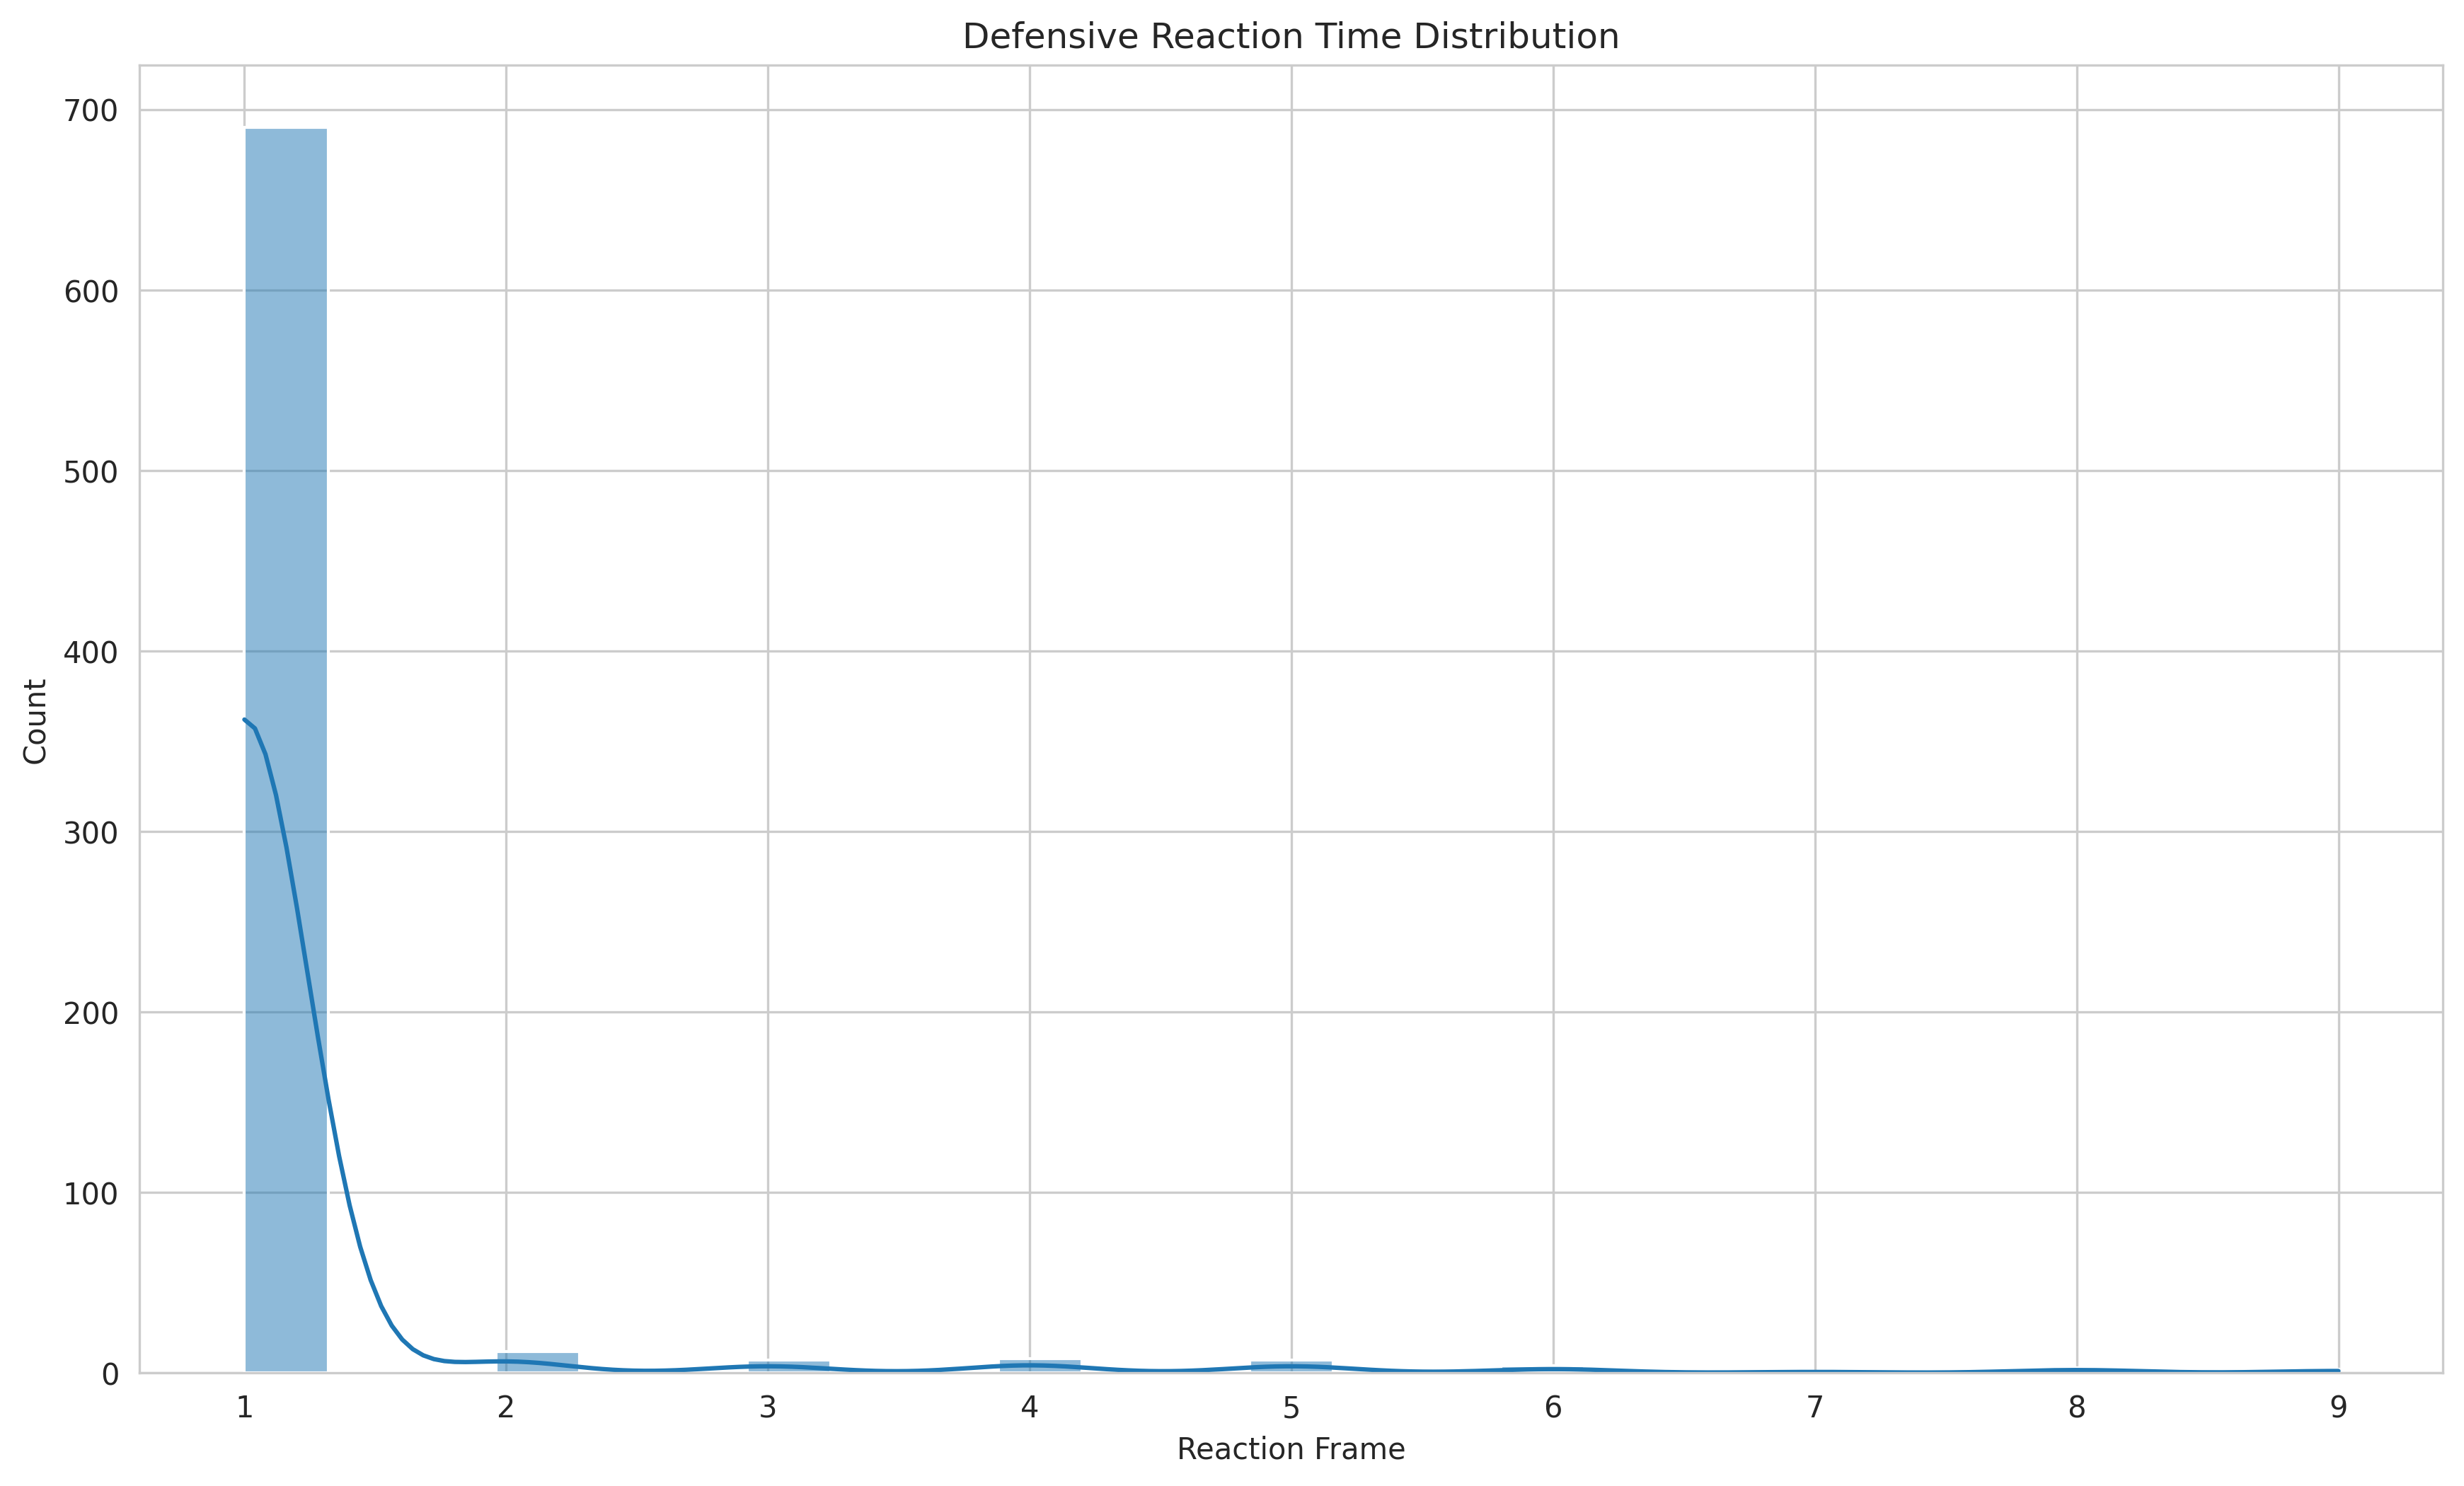

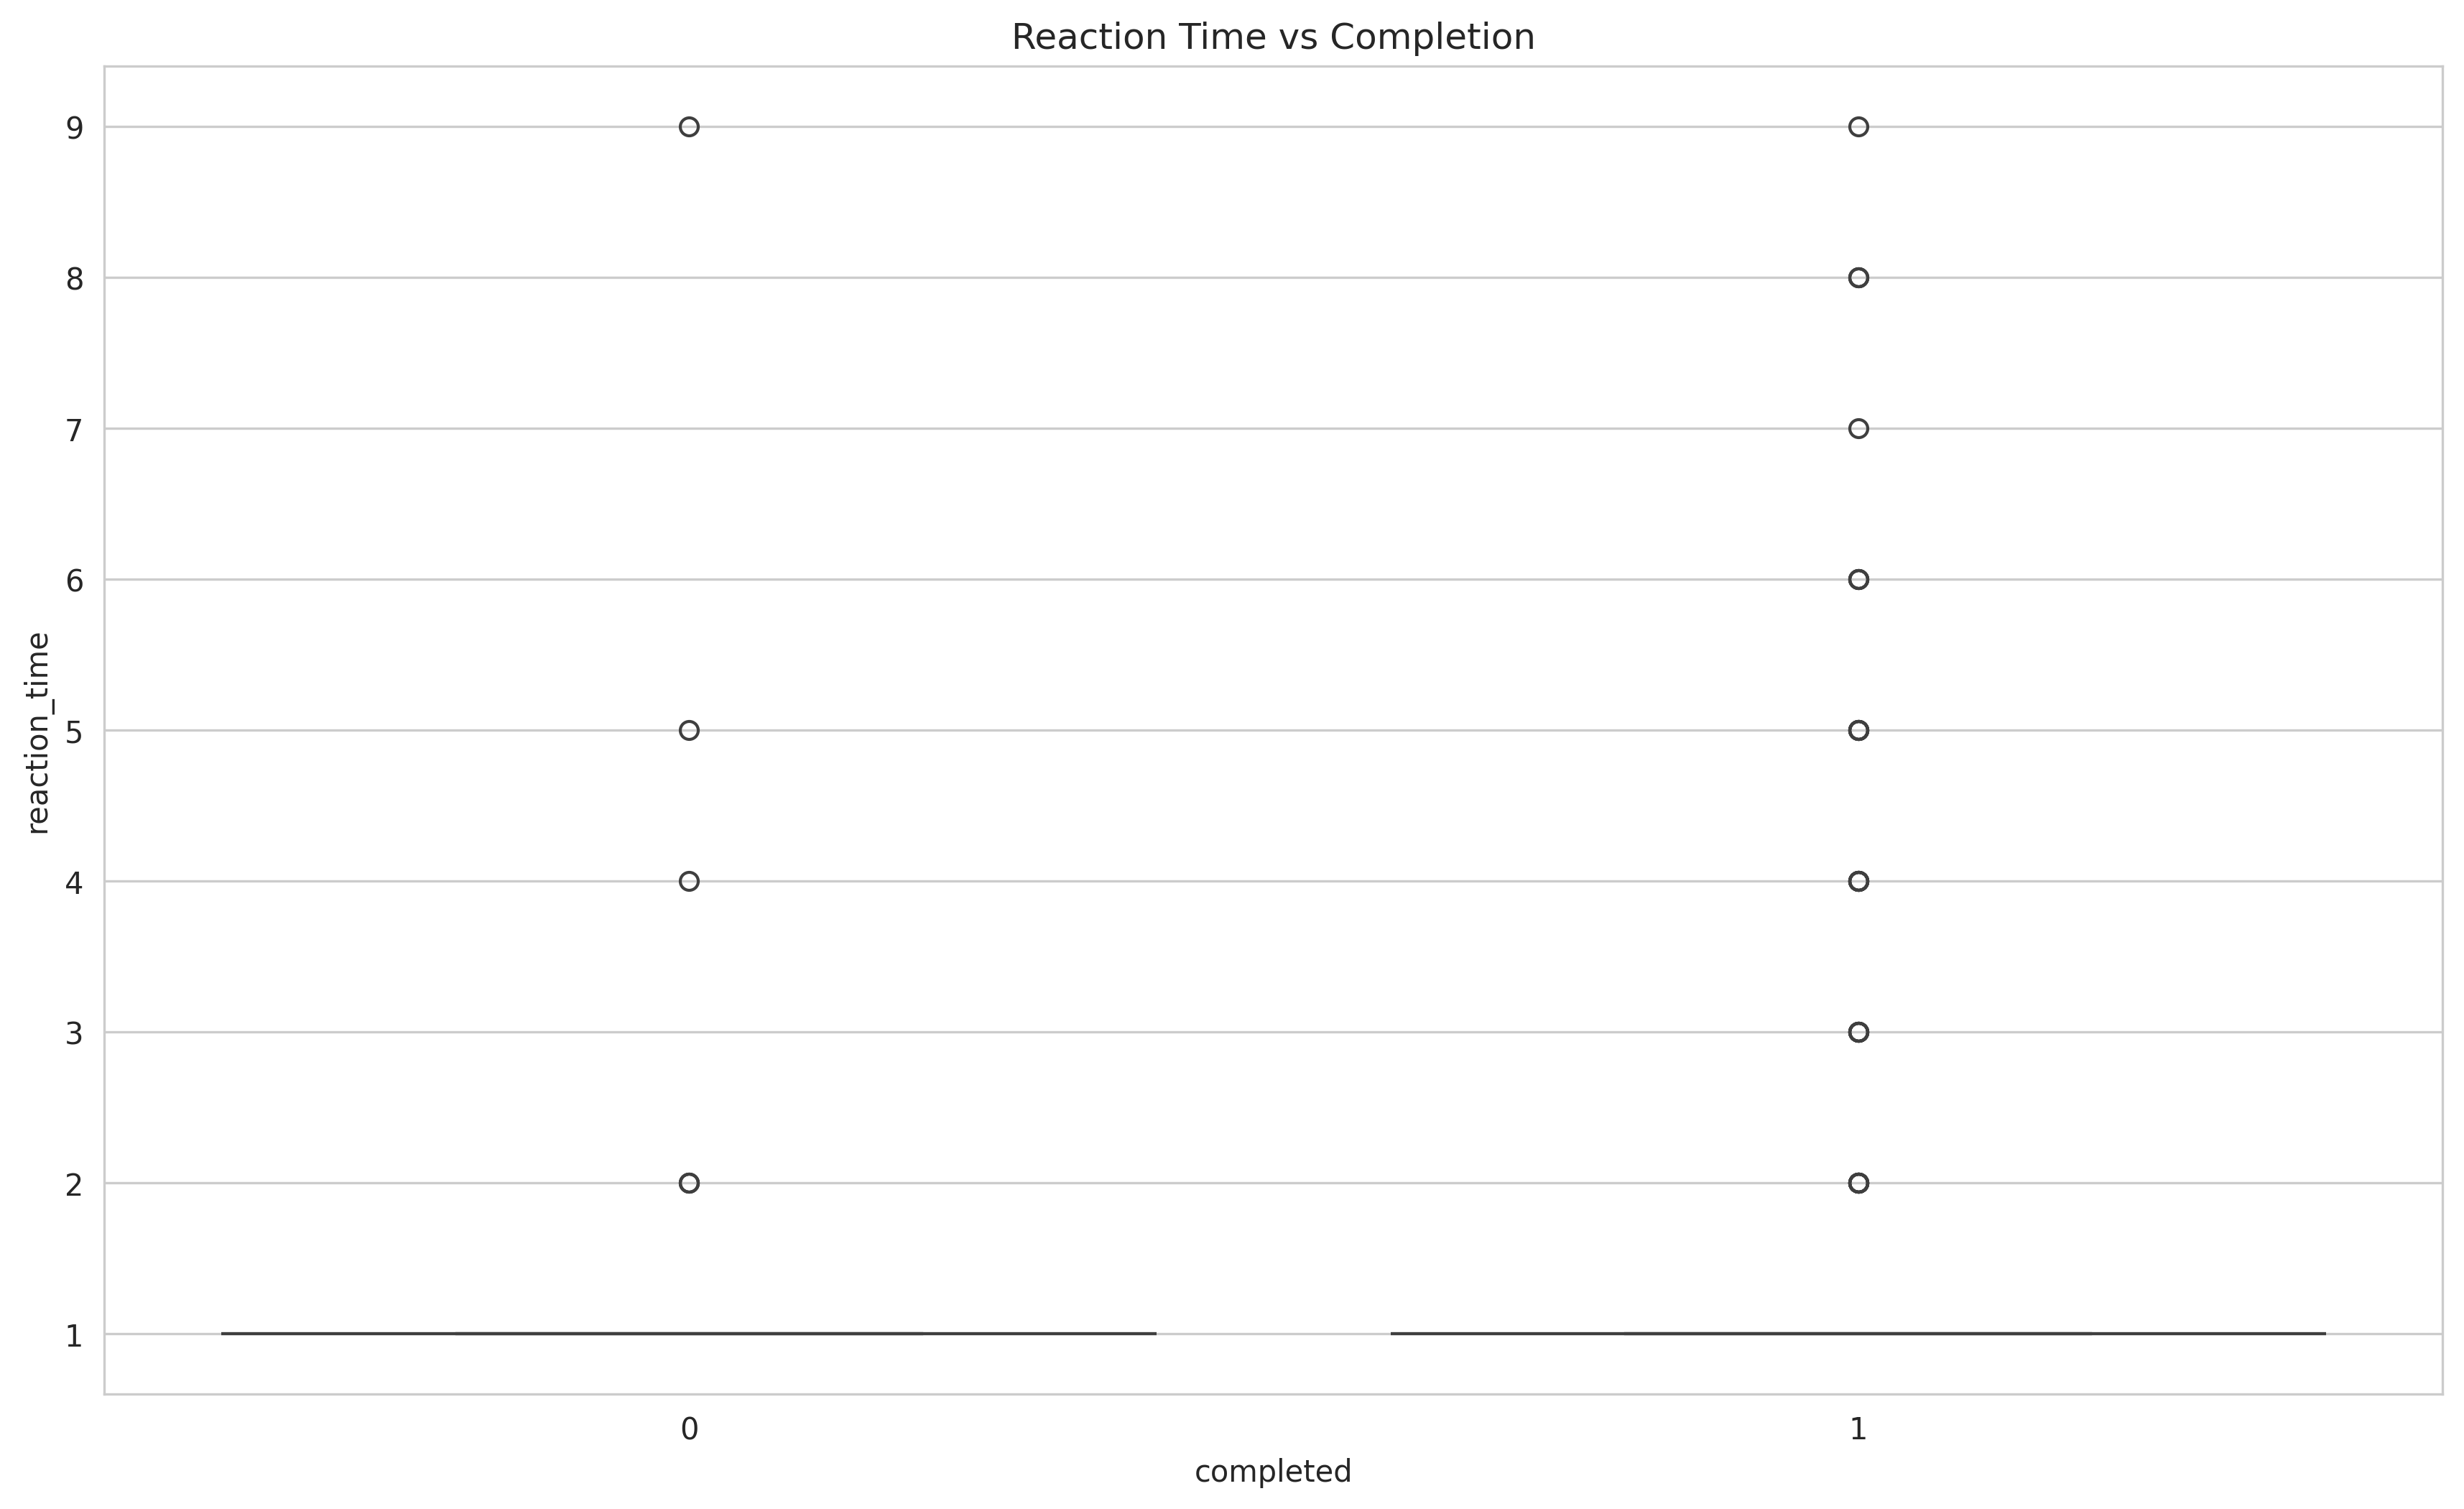

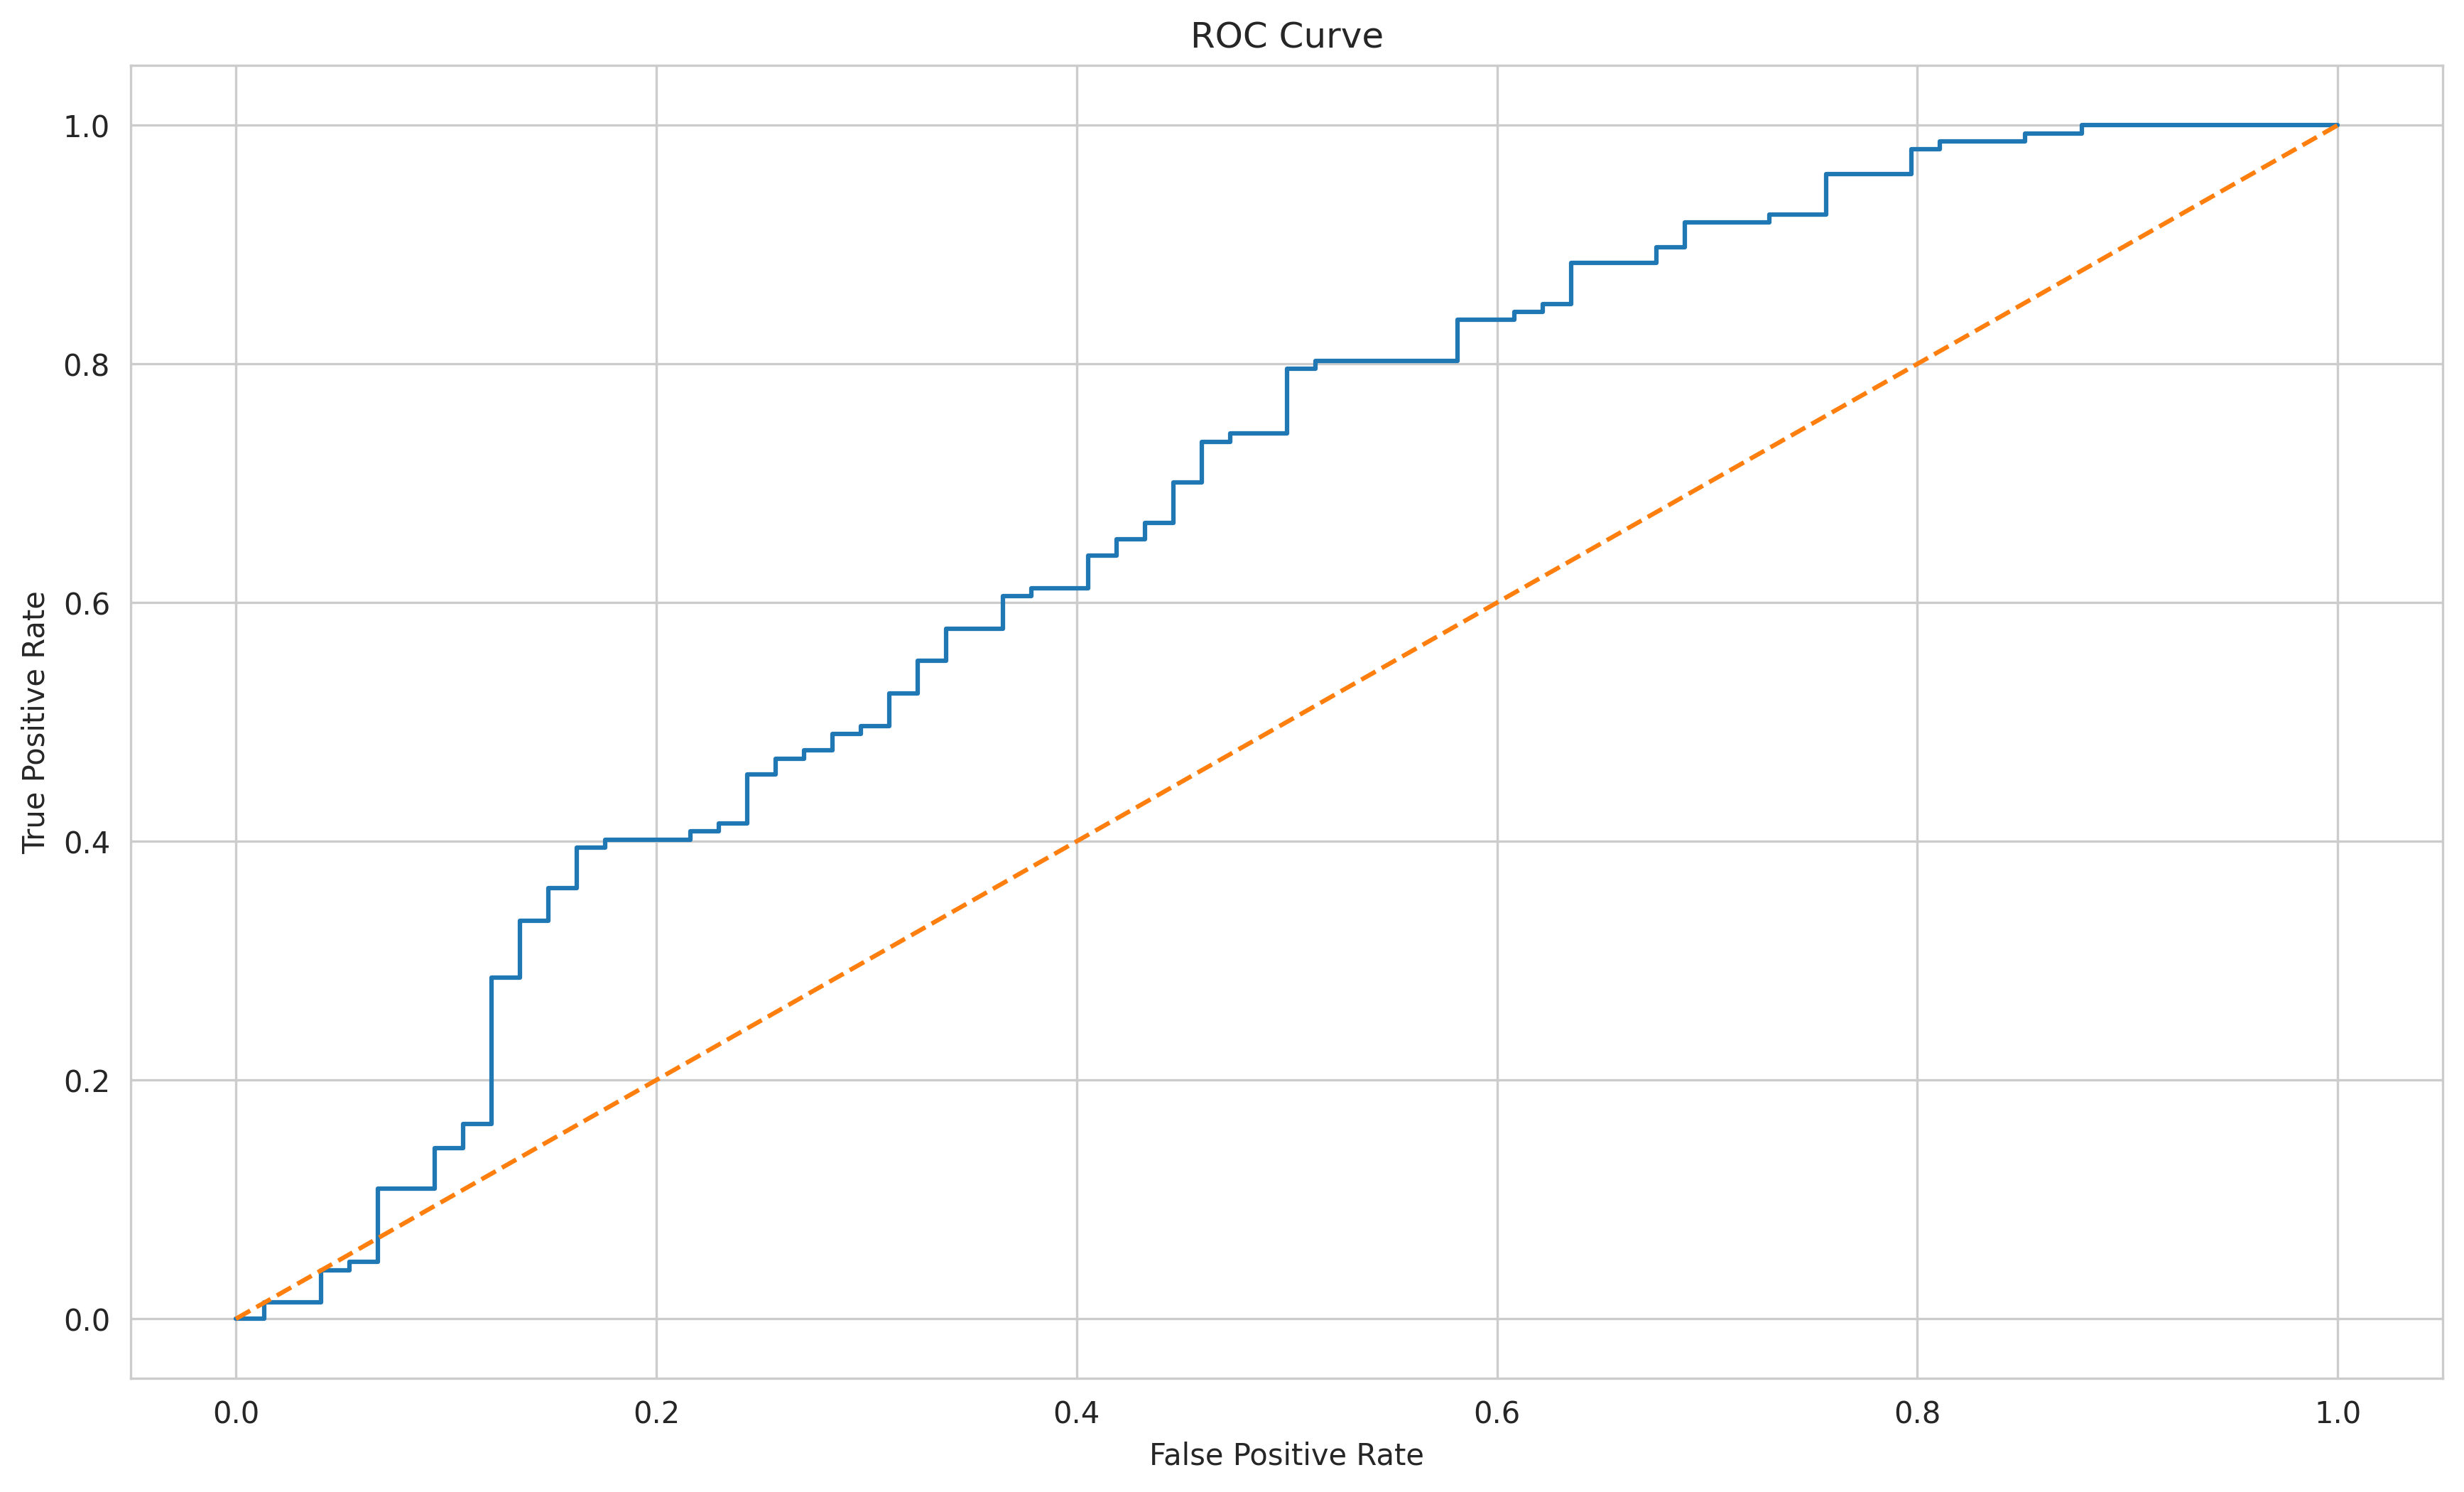

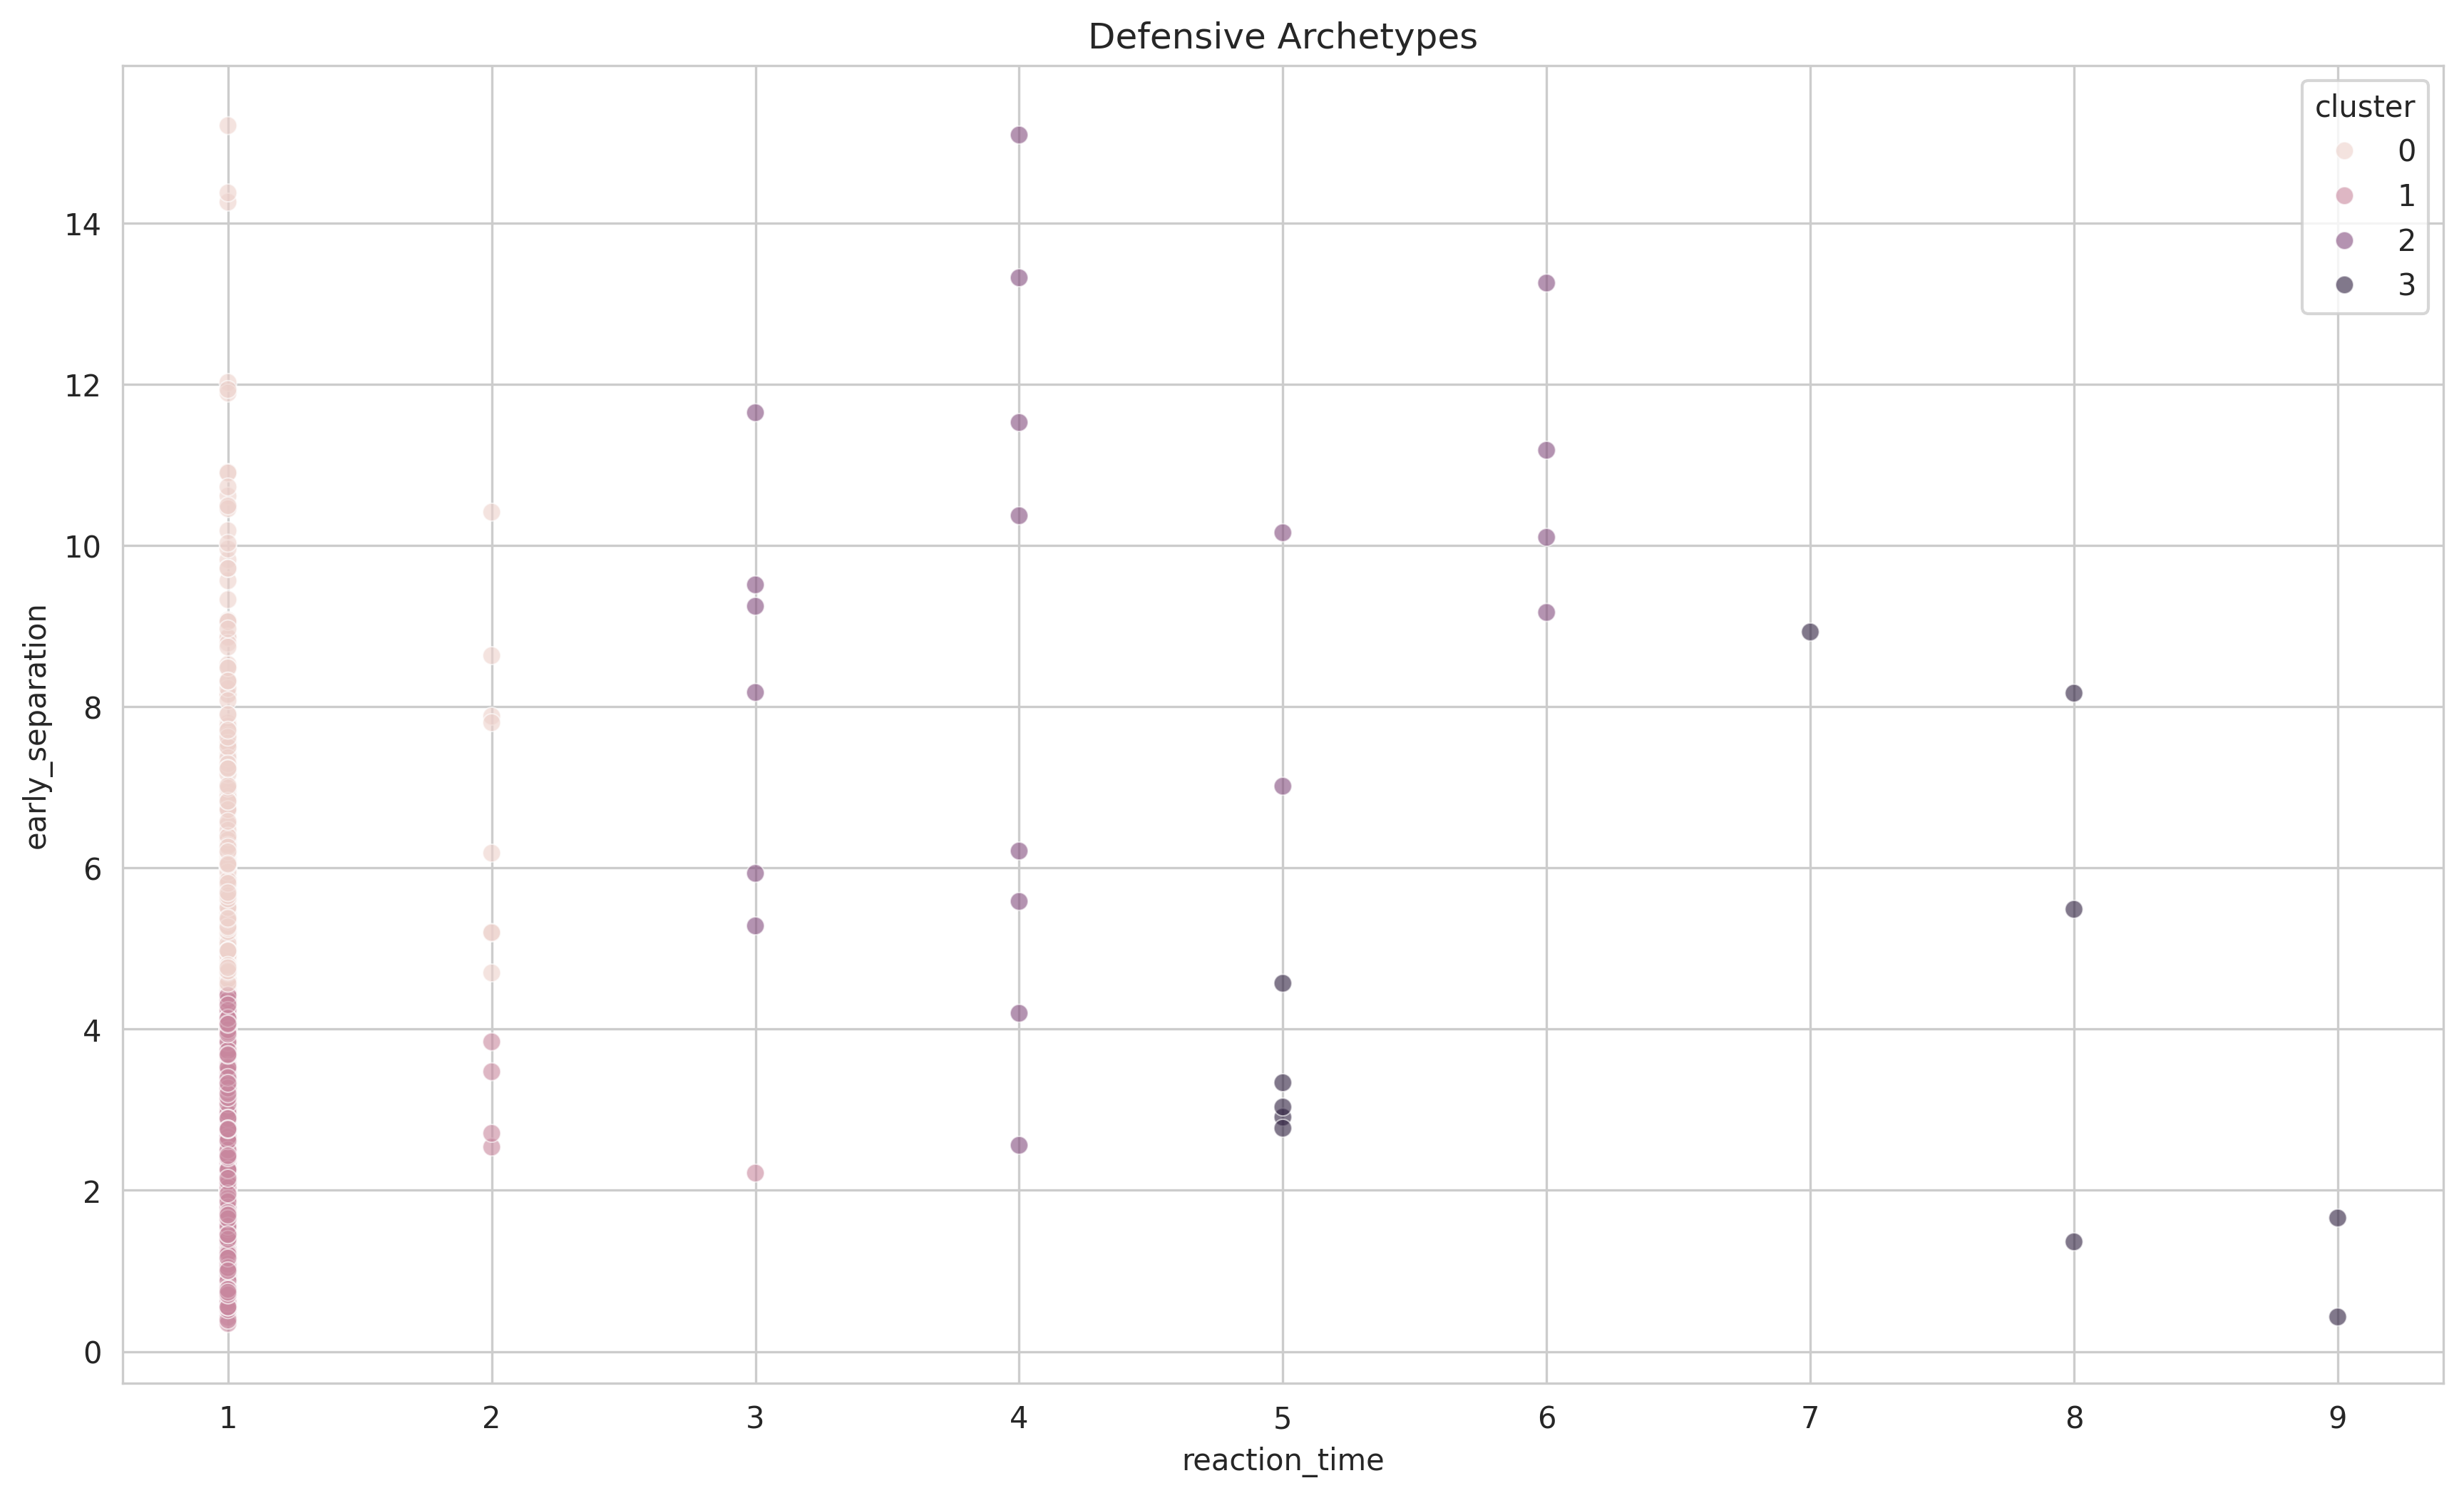


ROUTE EFFICIENCY
Average Efficiency: 1.0480541705378037

COVERAGE BREAKDOWN
Average Breakdown Frame: 3.5885558583106265

ANALYSIS COMPLETE.

VISUALIZATION PACK: ANIMATIONS + PLAY VIS

Selected play: Game 2023091100, Play 3167
Creating SIMPLE animation for Game 2023091100, Play 3167...
Saving SIMPLE animation (94 frames) -> /kaggle/working/play_animation_simple.gif
✓ Saved: /kaggle/working/play_animation_simple.gif
Creating BROADCAST animation for Game 2023091100, Play 3167...
Saving BROADCAST animation (94 frames) -> /kaggle/working/play_animation_broadcast.gif
✓ Saved: /kaggle/working/play_animation_broadcast.gif
Creating KEY FRAMES panel for Game 2023091100, Play 3167...
✓ Saved: /kaggle/working/play_frames.png
Creating SPEED TRAILS for Game 2023091100, Play 3167...
✓ Saved: /kaggle/working/speed_trails.png
Creating SEPARATION TIMELINE for Game 2023091100, Play 3167...
✓ Saved: /kaggle/working/separation_timeline.png
Creating DEFENSIVE HEATMAP (sampling up to 100 games)...
✓ Saved: 

In [2]:
# ============================================================
# NFL BIG DATA BOWL 2026 - COMBINED MASTER SCRIPT
# Includes:
#   A) ULTIMATE COMPREHENSIVE ANALYSIS (metrics + 8 PNGs + CSVs + report)
#   B) "The First 0.5 Seconds" Modeling Script (reaction time + early sep + LR + clustering)
#   C) VISUALIZATION PACK:
#       - Simple play animation GIF
#       - Broadcast-style animation GIF
#       - Static key frames panel PNG
#       - Speed trails PNG
#       - Separation timeline PNG
#       - Defensive heatmap PNG
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# GLOBAL STYLE
# ------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (14, 8)

# ------------------------------------------------------------
# PATHS (Kaggle-first, local fallback env vars)
# ------------------------------------------------------------
KAGGLE_BASE_PATH = "/kaggle/input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final"
LOCAL_SUPP_PATH = "/mnt/data/supplementary_data.csv"  # only if running here

def resolve_paths():
    if os.path.exists(KAGGLE_BASE_PATH):
        base = KAGGLE_BASE_PATH
        input_path = f"{base}/train/input_2023_w01.csv"
        output_path = f"{base}/train/output_2023_w01.csv"
        supp_path = f"{base}/supplementary_data.csv"
        return input_path, output_path, supp_path, True
    else:
        INPUT_LOCAL = os.environ.get("NFL_INPUT_LOCAL", "")
        OUTPUT_LOCAL = os.environ.get("NFL_OUTPUT_LOCAL", "")
        supp_path = LOCAL_SUPP_PATH if os.path.exists(LOCAL_SUPP_PATH) else ""
        return INPUT_LOCAL, OUTPUT_LOCAL, supp_path, False


# ============================================================
# C) VISUALIZATION PACK (YOUR STYLE)
# ============================================================

def create_football_field_simple():
    """Simple, clean football field"""
    fig, ax = plt.subplots(figsize=(12, 6.4))

    ax.add_patch(patches.Rectangle((0, 0), 120, 53.3,
                                   facecolor='#2E7D32', zorder=0))

    for yard in range(10, 111, 10):
        ax.plot([yard, yard], [0, 53.3], 'white', linewidth=2, alpha=0.7)

    for yard in [20, 30, 40, 50, 60, 70, 80, 90, 100]:
        num = min(yard - 10, 120 - yard)
        ax.text(yard, 5, str(num), ha='center', fontsize=18,
                color='white', weight='bold', zorder=10)
        ax.text(yard, 48, str(num), ha='center', fontsize=18,
                color='white', weight='bold', zorder=10)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.axis('off')

    return fig, ax


def create_simple_play_animation(input_df, output_df, game_id, play_id,
                                 save_path):
    """Create a simple, working GIF animation of a play"""
    print(f"Creating SIMPLE animation for Game {game_id}, Play {play_id}...")

    input_play = input_df[(input_df['game_id'] == game_id) &
                          (input_df['play_id'] == play_id)]
    output_play = output_df[(output_df['game_id'] == game_id) &
                            (output_df['play_id'] == play_id)]

    if len(input_play) == 0 or len(output_play) == 0:
        print("No data found for this play")
        return None

    output_play = output_play.merge(
        input_play[['nfl_id', 'player_side', 'player_role', 'player_name']].drop_duplicates(),
        on='nfl_id', how='left'
    )

    ball_x = input_play['ball_land_x'].iloc[0]
    ball_y = input_play['ball_land_y'].iloc[0]

    fig, ax = create_football_field_simple()

    ax.scatter([ball_x], [ball_y], c='gold', s=300, marker='*',
               edgecolors='black', linewidth=2, zorder=20, label='Ball Landing')

    offense_scat = ax.scatter([], [], c='red', s=150, edgecolors='white',
                              linewidth=2, zorder=15)
    defense_scat = ax.scatter([], [], c='blue', s=150, edgecolors='white',
                              linewidth=2, zorder=15)
    target_scat = ax.scatter([], [], c='yellow', s=250, marker='D',
                             edgecolors='black', linewidth=2, zorder=17)

    frame_text = ax.text(5, 50, '', fontsize=14, weight='bold',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.legend(loc='upper right', fontsize=10)

    num_frames = int(output_play['frame_id'].max())

    def animate(frame_num):
        current_frame = frame_num + 1
        frame_data = output_play[output_play['frame_id'] == current_frame]

        if len(frame_data) == 0:
            return offense_scat, defense_scat, target_scat, frame_text

        offense = frame_data[frame_data['player_side'] == 'Offense']
        defense = frame_data[frame_data['player_side'] == 'Defense']
        target = frame_data[frame_data['player_role'] == 'Targeted Receiver']

        if len(offense) > 0:
            offense_scat.set_offsets(offense[['x', 'y']].values)
        if len(defense) > 0:
            defense_scat.set_offsets(defense[['x', 'y']].values)
        if len(target) > 0:
            target_scat.set_offsets(target[['x', 'y']].values)

        frame_text.set_text(f'Frame {current_frame}/{num_frames}')
        return offense_scat, defense_scat, target_scat, frame_text

    anim = FuncAnimation(fig, animate, frames=num_frames,
                         interval=100, blit=True, repeat=True)

    print(f"Saving SIMPLE animation ({num_frames} frames) -> {save_path}")
    writer = PillowWriter(fps=10)
    anim.save(save_path, writer=writer)
    plt.close(fig)

    print(f"✓ Saved: {save_path}")
    return save_path


def create_static_frames(input_df, output_df, game_id, play_id,
                         frames_to_show, save_path):
    """Key frames side-by-side"""
    print(f"Creating KEY FRAMES panel for Game {game_id}, Play {play_id}...")

    input_play = input_df[(input_df['game_id'] == game_id) &
                          (input_df['play_id'] == play_id)]
    output_play = output_df[(output_df['game_id'] == game_id) &
                            (output_df['play_id'] == play_id)]

    if len(input_play) == 0 or len(output_play) == 0:
        print("No data found")
        return None

    output_play = output_play.merge(
        input_play[['nfl_id', 'player_side', 'player_role']].drop_duplicates(),
        on='nfl_id', how='left'
    )

    ball_x = input_play['ball_land_x'].iloc[0]
    ball_y = input_play['ball_land_y'].iloc[0]

    n_frames = len(frames_to_show)
    fig, axes = plt.subplots(1, n_frames, figsize=(4*n_frames, 5))
    if n_frames == 1:
        axes = [axes]

    for idx, frame_num in enumerate(frames_to_show):
        ax = axes[idx]
        ax.add_patch(patches.Rectangle((0, 0), 120, 53.3,
                                       facecolor='#2E7D32', zorder=0))
        for yard in range(10, 111, 20):
            ax.plot([yard, yard], [0, 53.3], 'white', linewidth=1, alpha=0.5)

        ax.set_xlim(0, 120)
        ax.set_ylim(0, 53.3)
        ax.axis('off')
        ax.set_title(f'Frame {frame_num}', fontsize=12, weight='bold')

        ax.scatter([ball_x], [ball_y], c='gold', s=200, marker='*',
                   edgecolors='black', linewidth=2, zorder=20)

        frame_data = output_play[output_play['frame_id'] == frame_num]
        offense = frame_data[frame_data['player_side'] == 'Offense']
        defense = frame_data[frame_data['player_side'] == 'Defense']
        target = frame_data[frame_data['player_role'] == 'Targeted Receiver']

        if len(offense) > 0:
            ax.scatter(offense['x'], offense['y'], c='red', s=100,
                       edgecolors='white', linewidth=1.5, zorder=15)
        if len(defense) > 0:
            ax.scatter(defense['x'], defense['y'], c='blue', s=100,
                       edgecolors='white', linewidth=1.5, zorder=15)
        if len(target) > 0:
            ax.scatter(target['x'], target['y'], c='yellow', s=200,
                       marker='D', edgecolors='black', linewidth=2, zorder=17)

    plt.suptitle(f'Game {game_id} | Play {play_id} | Key Frames',
                 fontsize=14, weight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"✓ Saved: {save_path}")
    return save_path


# -------- Broadcast-style field + animation + heatmap/trails/timeline --------

def create_football_field(highlight_los=None, highlight_target=None):
    """Realistic football field"""
    fig, ax = plt.subplots(figsize=(14, 7.4))

    ax.add_patch(patches.Rectangle((0, 0), 120, 53.3,
                                   facecolor='#196B24', zorder=0))

    ax.add_patch(patches.Rectangle((0, 0), 10, 53.3,
                                   facecolor='#0E4C1F', alpha=0.5, zorder=1))
    ax.add_patch(patches.Rectangle((110, 0), 10, 53.3,
                                   facecolor='#0E4C1F', alpha=0.5, zorder=1))

    for yard in range(10, 111, 5):
        ax.plot([yard, yard], [0, 53.3], color='white', linewidth=1.5, alpha=0.5, zorder=2)
    for yard in range(10, 111, 10):
        ax.plot([yard, yard], [0, 53.3], color='white', linewidth=2, zorder=2)

    for yard in range(11, 110):
        ax.plot([yard, yard], [18.5, 19], color='white', linewidth=1, zorder=2)
        ax.plot([yard, yard], [34.3, 34.8], color='white', linewidth=1, zorder=2)

    for yard in range(20, 111, 10):
        yard_num = yard - 10 if yard <= 60 else 120 - yard
        ax.text(yard, 5, str(yard_num), ha='center', va='center',
                fontsize=20, color='white', weight='bold', zorder=3)
        ax.text(yard, 48.3, str(yard_num), ha='center', va='center',
                fontsize=20, color='white', weight='bold', zorder=3)

    if highlight_los is not None:
        ax.axvline(highlight_los, color='yellow', linewidth=3,
                   linestyle='--', alpha=0.8, zorder=4, label='Line of Scrimmage')

    if highlight_target is not None:
        ax.add_patch(patches.Circle(highlight_target, 2,
                                    facecolor='yellow', alpha=0.3,
                                    edgecolor='yellow', linewidth=2, zorder=3))

    ax.set_xlim(-5, 125)
    ax.set_ylim(-2, 55.3)
    ax.axis('off')
    return fig, ax


def animate_play_broadcast(input_df, output_df, game_id, play_id, save_path):
    """Broadcast-like animation GIF"""
    print(f"Creating BROADCAST animation for Game {game_id}, Play {play_id}...")

    input_play = input_df[(input_df['game_id'] == game_id) &
                          (input_df['play_id'] == play_id)]
    output_play = output_df[(output_df['game_id'] == game_id) &
                            (output_df['play_id'] == play_id)]

    if len(input_play) == 0 or len(output_play) == 0:
        print("No data found for this play")
        return None

    output_play = output_play.merge(
        input_play[['nfl_id', 'player_side', 'player_role', 'player_position',
                    'player_name']].drop_duplicates(),
        on='nfl_id', how='left'
    )

    ball_x = input_play['ball_land_x'].iloc[0]
    ball_y = input_play['ball_land_y'].iloc[0]
    los = input_play['absolute_yardline_number'].iloc[0] if 'absolute_yardline_number' in input_play.columns else None

    fig, ax = create_football_field(highlight_los=los, highlight_target=(ball_x, ball_y))

    offense_scatter = ax.scatter([], [], c='red', s=200, edgecolors='white',
                                 linewidth=2, zorder=10, label='Offense')
    defense_scatter = ax.scatter([], [], c='blue', s=200, edgecolors='white',
                                 linewidth=2, zorder=10, label='Defense')
    target_scatter = ax.scatter([], [], c='red', s=400, marker='*',
                                edgecolors='yellow', linewidth=3,
                                zorder=15, label='Target')
    passer_scatter = ax.scatter([], [], c='darkred', s=250, marker='s',
                                edgecolors='white', linewidth=2,
                                zorder=15, label='QB')

    ax.scatter([ball_x], [ball_y], c='brown', s=150,
               marker='o', edgecolors='black', linewidth=2,
               zorder=20, label='Ball Location')

    frame_text = ax.text(115, 50, '', fontsize=14, weight='bold',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    play_desc = input_play['play_description'].iloc[0] if 'play_description' in input_play.columns else ''
    ax.set_title(f'Game {game_id} | Play {play_id}\n{str(play_desc)[:80]}...',
                 fontsize=12, pad=20)
    ax.legend(loc='upper left', fontsize=10)

    num_frames = int(output_play['frame_id'].max())

    def update(frame):
        frame_data = output_play[output_play['frame_id'] == frame + 1]
        if len(frame_data) == 0:
            return offense_scatter, defense_scatter, target_scatter, passer_scatter, frame_text

        offense = frame_data[frame_data['player_side'] == 'Offense']
        defense = frame_data[frame_data['player_side'] == 'Defense']
        target = frame_data[frame_data['player_role'] == 'Targeted Receiver']
        passer = frame_data[frame_data['player_role'] == 'Passer']

        if len(offense) > 0:
            offense_scatter.set_offsets(offense[['x', 'y']].values)
        if len(defense) > 0:
            defense_scatter.set_offsets(defense[['x', 'y']].values)
        if len(target) > 0:
            target_scatter.set_offsets(target[['x', 'y']].values)
        if len(passer) > 0:
            passer_scatter.set_offsets(passer[['x', 'y']].values)

        frame_text.set_text(f'Frame {frame + 1}/{num_frames}')
        return offense_scatter, defense_scatter, target_scatter, passer_scatter, frame_text

    anim = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True, repeat=True)
    print(f"Saving BROADCAST animation ({num_frames} frames) -> {save_path}")
    writer = PillowWriter(fps=10)
    anim.save(save_path, writer=writer)
    plt.close(fig)

    print(f"✓ Saved: {save_path}")
    return save_path


def create_speed_trails(input_df, output_df, game_id, play_id, save_path):
    """Player trails color-coded by side, width/alpha by speed"""
    print(f"Creating SPEED TRAILS for Game {game_id}, Play {play_id}...")

    input_play = input_df[(input_df['game_id'] == game_id) &
                          (input_df['play_id'] == play_id)]
    output_play = output_df[(output_df['game_id'] == game_id) &
                            (output_df['play_id'] == play_id)]

    if len(input_play) == 0 or len(output_play) == 0:
        print("No data found for this play")
        return None

    ball_x = input_play['ball_land_x'].iloc[0]
    ball_y = input_play['ball_land_y'].iloc[0]
    los = input_play['absolute_yardline_number'].iloc[0] if 'absolute_yardline_number' in input_play.columns else None

    output_play = output_play.merge(
        input_play[['nfl_id', 'player_side', 'player_role', 'player_name']].drop_duplicates(),
        on='nfl_id', how='left'
    )

    fig, ax = create_football_field(highlight_los=los, highlight_target=(ball_x, ball_y))

    for nfl_id in output_play['nfl_id'].unique():
        player_data = output_play[output_play['nfl_id'] == nfl_id].sort_values('frame_id')
        if len(player_data) < 2:
            continue

        dx = player_data['x'].diff()
        dy = player_data['y'].diff()
        speed = np.sqrt(dx**2 + dy**2) * 10  # approx yards/sec

        color = 'red' if player_data.iloc[0]['player_side'] == 'Offense' else 'blue'

        for i in range(1, len(player_data)):
            x_vals = [player_data.iloc[i-1]['x'], player_data.iloc[i]['x']]
            y_vals = [player_data.iloc[i-1]['y'], player_data.iloc[i]['y']]
            lw = 0.5 + min(speed.iloc[i], 10) / 5
            alpha = 0.3 + min(speed.iloc[i], 10) / 20
            ax.plot(x_vals, y_vals, color=color, linewidth=lw, alpha=alpha, zorder=5)

    ax.set_title(f'Player Movement Trails\nGame {game_id} | Play {play_id}',
                 fontsize=14, weight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {save_path}")
    return save_path


def create_separation_timeline(input_df, output_df, game_id, play_id, save_path):
    """Separation between target and nearest defender over frames"""
    print(f"Creating SEPARATION TIMELINE for Game {game_id}, Play {play_id}...")

    input_play = input_df[(input_df['game_id'] == game_id) &
                          (input_df['play_id'] == play_id)]
    output_play = output_df[(output_df['game_id'] == game_id) &
                            (output_df['play_id'] == play_id)]

    if len(input_play) == 0 or len(output_play) == 0:
        print("No data found for this play")
        return None

    output_play = output_play.merge(
        input_play[['nfl_id', 'player_side', 'player_role']].drop_duplicates(),
        on='nfl_id', how='left'
    )

    target_rows = input_play[input_play['player_role'] == 'Targeted Receiver']
    if len(target_rows) == 0:
        print("No targeted receiver found")
        return None

    target_id = target_rows['nfl_id'].iloc[0]

    separations = []
    for frame in sorted(output_play['frame_id'].unique()):
        frame_data = output_play[output_play['frame_id'] == frame]
        target_pos = frame_data[frame_data['nfl_id'] == target_id][['x', 'y']].values
        defenders = frame_data[frame_data['player_side'] == 'Defense'][['x', 'y']].values
        if len(target_pos) > 0 and len(defenders) > 0:
            distances = np.sqrt(((defenders - target_pos) ** 2).sum(axis=1))
            separations.append({'frame': frame, 'separation': distances.min()})

    sep_df = pd.DataFrame(separations)
    if len(sep_df) == 0:
        print("Could not compute separation series")
        return None

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(sep_df['frame'], sep_df['separation'], linewidth=3,
            color='green', marker='o', markersize=6)
    ax.fill_between(sep_df['frame'], 0, sep_df['separation'], alpha=0.3, color='green')

    ax.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 yard (tight)')
    ax.axhline(3, color='orange', linestyle='--', alpha=0.5, label='3 yards (contested)')
    ax.axhline(5, color='blue', linestyle='--', alpha=0.5, label='5 yards (open)')

    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Separation from Nearest Defender (yards)', fontsize=12)
    ax.set_title(f'Receiver Separation Timeline\nGame {game_id} | Play {play_id}',
                 fontsize=14, weight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {save_path}")
    return save_path


def create_defensive_heatmap(output_df, input_df, save_path, max_games=100):
    """Heat map where defenders end up at final frame (sampled games)"""
    print(f"Creating DEFENSIVE HEATMAP (sampling up to {max_games} games)...")

    all_plays = []
    game_ids = list(output_df['game_id'].unique()[:max_games])
    for game_id in game_ids:
        game_output = output_df[output_df['game_id'] == game_id]
        game_input = input_df[input_df['game_id'] == game_id]
        merged = game_output.merge(
            game_input[['nfl_id', 'player_side', 'player_role']].drop_duplicates(),
            on='nfl_id', how='left'
        )
        all_plays.append(merged)

    if len(all_plays) == 0:
        print("No data to build heatmap")
        return None

    combined = pd.concat(all_plays, ignore_index=True)
    max_frames = combined.groupby(['game_id', 'play_id'])['frame_id'].max().reset_index()
    max_frames.columns = ['game_id', 'play_id', 'max_frame']
    combined = combined.merge(max_frames, on=['game_id', 'play_id'])
    final_positions = combined[(combined['frame_id'] == combined['max_frame']) &
                              (combined['player_side'] == 'Defense')]

    fig, ax = create_football_field()

    heatmap, xedges, yedges = np.histogram2d(
        final_positions['x'], final_positions['y'],
        bins=[60, 27], range=[[0, 120], [0, 53.3]]
    )

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    im = ax.imshow(heatmap.T, extent=extent, origin='lower',
                   cmap='YlOrRd', alpha=0.6, zorder=5)

    plt.colorbar(im, ax=ax, label='Defender Frequency')
    ax.set_title('Defensive Player Heat Map at Ball Arrival', fontsize=16, weight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {save_path}")
    return save_path


def pick_good_play(output_df, min_rows=200):
    """Pick a play with enough tracking rows (usually better animation)"""
    sample_plays = output_df.groupby(['game_id', 'play_id']).size().reset_index(name='count')
    sample_plays = sample_plays[sample_plays['count'] > min_rows].sort_values('count', ascending=False)
    if len(sample_plays) == 0:
        return None, None
    return int(sample_plays.iloc[0]['game_id']), int(sample_plays.iloc[0]['play_id'])


# ============================================================
# A) "ULTIMATE COMPREHENSIVE ANALYSIS" (YOUR SCRIPT)
# ============================================================

def run_ultimate_comprehensive_analysis(input_w1, output_w1, supplementary, workdir):
    print("="*80)
    print(" "*20 + "NFL BIG DATA BOWL 2026")
    print(" "*15 + "COMPREHENSIVE TRACKING ANALYSIS")
    print("="*80)
    print("\n🏈 Analyzing player movement during pass plays...")
    print("📊 Calculating 10+ metrics across 5 major analysis categories")
    print("📈 Generating 15+ publication-ready visualizations\n")

    print("="*80)
    print("SECTION 1: LOADING DATA")
    print("="*80)

    print(f"✓ Input tracking data:     {len(input_w1):>10,} records")
    print(f"✓ Output tracking data:    {len(output_w1):>10,} records")
    print(f"✓ Supplementary play data: {len(supplementary):>10,} plays")
    print(f"\n✓ Unique games:            {input_w1['game_id'].nunique():>10,}")
    print(f"✓ Unique plays:            {input_w1.groupby(['game_id','play_id']).ngroups:>10,}")
    print(f"✓ Unique players:          {input_w1['nfl_id'].nunique():>10,}")

    print("\n" + "="*80)
    print("SECTION 2: SEPARATION AT CATCH POINT ANALYSIS")
    print("="*80)

    def calculate_comprehensive_separation(input_df, output_df, supp_df, sample_size=2500):
        results = []
        for idx, play_info in supp_df.sample(n=sample_size, random_state=42).iterrows():
            if idx % 500 == 0:
                print(f"  Processing play {idx}/{sample_size}...")

            game_id = play_info['game_id']
            play_id = play_info['play_id']

            input_play = input_df[(input_df['game_id'] == game_id) &
                                  (input_df['play_id'] == play_id)]
            output_play = output_df[(output_df['game_id'] == game_id) &
                                    (output_df['play_id'] == play_id)]

            if len(input_play) == 0 or len(output_play) == 0:
                continue

            target_rows = input_play[input_play['player_role'] == 'Targeted Receiver']
            if len(target_rows) == 0:
                continue

            target_id = target_rows['nfl_id'].iloc[0]
            target_name = target_rows['player_name'].iloc[0]
            target_pos = target_rows['player_position'].iloc[0]

            if target_pos in ['RB', 'FB', 'HB']:
                position_group = 'RB'
            elif target_pos in ['WR']:
                position_group = 'WR'
            elif target_pos in ['TE']:
                position_group = 'TE'
            else:
                continue

            output_play = output_play.merge(
                input_play[['nfl_id', 'player_side']].drop_duplicates(),
                on='nfl_id', how='left'
            )

            max_frame = output_play['frame_id'].max()
            final_frame = output_play[output_play['frame_id'] == max_frame]

            target_pos_coords = final_frame[final_frame['nfl_id'] == target_id][['x', 'y']].values
            defenders = final_frame[final_frame['player_side'] == 'Defense'][['x', 'y']].values

            if len(target_pos_coords) > 0 and len(defenders) > 0:
                distances = np.sqrt(((defenders - target_pos_coords) ** 2).sum(axis=1))
                min_sep = distances.min()
                num_defenders_close = (distances <= 3).sum()

                results.append({
                    'game_id': game_id,
                    'play_id': play_id,
                    'player_name': target_name,
                    'position': position_group,
                    'route': play_info['route_of_targeted_receiver'],
                    'coverage': play_info['team_coverage_type'],
                    'separation': min_sep,
                    'defenders_within_3': num_defenders_close,
                    'completed': 1 if play_info['pass_result'] == 'C' else 0,
                    'yards': play_info['yards_gained'],
                    'epa': play_info['expected_points_added'],
                    'down': play_info['down'],
                    'yards_to_go': play_info['yards_to_go'],
                    'pass_length': play_info['pass_length']
                })

        return pd.DataFrame(results)

    print("\nCalculating separation metrics for all plays...")
    separation_df = calculate_comprehensive_separation(input_w1, output_w1, supplementary)
    print(f"✓ Analyzed {len(separation_df):,} plays with complete tracking data\n")

    print("OVERALL SEPARATION STATISTICS:")
    print("-" * 50)
    print(f"  Mean separation:     {separation_df['separation'].mean():.2f} yards")
    print(f"  Median separation:   {separation_df['separation'].median():.2f} yards")
    print(f"  Std deviation:       {separation_df['separation'].std():.2f} yards")
    print(f"  Min separation:      {separation_df['separation'].min():.2f} yards")
    print(f"  Max separation:      {separation_df['separation'].max():.2f} yards")

    completed = separation_df[separation_df['completed'] == 1]['separation']
    incomplete = separation_df[separation_df['completed'] == 0]['separation']
    print(f"\n  Completed passes:    {completed.mean():.2f} yards")
    print(f"  Incomplete passes:   {incomplete.mean():.2f} yards")
    print(f"  Difference:          {completed.mean() - incomplete.mean():.2f} yards")

    t_stat, p_val = stats.ttest_ind(completed, incomplete)
    print(f"  Statistical sig:     p = {p_val:.6f} {'***' if p_val < 0.001 else ''}")

    print("\n" + "="*80)
    print("SECTION 3: POSITION GROUP ANALYSIS")
    print("="*80)

    pos_stats = separation_df.groupby('position').agg({
        'separation': ['mean', 'std', 'count'],
        'completed': 'mean',
        'yards': 'mean',
        'epa': 'mean',
        'defenders_within_3': 'mean'
    })
    pos_stats.columns = ['Avg_Sep', 'Std_Sep', 'Targets', 'Comp_Rate', 'Avg_Yards', 'Avg_EPA', 'Avg_Def_Close']
    print("\nPOSITION COMPARISON:")
    print("-" * 50)
    print(pos_stats.round(3))

    rb_sep = separation_df[separation_df['position'] == 'RB']['separation']
    wr_sep = separation_df[separation_df['position'] == 'WR']['separation']
    te_sep = separation_df[separation_df['position'] == 'TE']['separation']

    print("\nSTATISTICAL SIGNIFICANCE TESTS:")
    print("-" * 50)
    t_rb_wr, p_rb_wr = stats.ttest_ind(rb_sep, wr_sep)
    print(f"  RB vs WR:  t={t_rb_wr:.2f}, p={p_rb_wr:.6f} {'***' if p_rb_wr < 0.001 else ''}")
    print(f"  Difference: {rb_sep.mean() - wr_sep.mean():.2f} yards ({(rb_sep.mean() - wr_sep.mean())/wr_sep.mean()*100:.1f}%)")
    t_rb_te, p_rb_te = stats.ttest_ind(rb_sep, te_sep)
    print(f"  RB vs TE:  t={t_rb_te:.2f}, p={p_rb_te:.6f} {'***' if p_rb_te < 0.001 else ''}")

    print("\nTOP 15 PLAYERS BY SEPARATION:")
    print("-" * 50)
    player_stats = separation_df.groupby(['player_name', 'position']).agg({
        'separation': 'mean',
        'completed': 'mean',
        'yards': 'mean',
        'epa': 'mean',
        'player_name': 'size'
    }).round(3)
    player_stats.columns = ['Avg_Sep', 'Catch_Rate', 'YPT', 'EPA', 'Targets']
    player_stats = player_stats[player_stats['Targets'] >= 5].sort_values('Avg_Sep', ascending=False)
    print(player_stats.head(15))

    print("\n" + "="*80)
    print("SECTION 4: ROUTE VS COVERAGE MATCHUP ANALYSIS")
    print("="*80)

    pivot_sep = separation_df.pivot_table(values='separation', index='route', columns='coverage', aggfunc='mean')
    print("\nROUTE VS COVERAGE SEPARATION MATRIX (yards):")
    print("-" * 80)
    print(pivot_sep.round(2))

    best_matchups = separation_df.groupby(['route', 'coverage']).agg({
        'separation': ['mean', 'count'],
        'completed': 'mean',
        'epa': 'mean'
    })
    best_matchups.columns = ['Avg_Sep', 'Plays', 'Comp_Rate', 'EPA']
    best_matchups = best_matchups[best_matchups['Plays'] >= 5].sort_values('Avg_Sep', ascending=False)

    print("\nTOP 10 ROUTE-COVERAGE COMBINATIONS (Highest Separation):")
    print("-" * 80)
    print(best_matchups.head(10))

    print("\nWORST 10 ROUTE-COVERAGE COMBINATIONS (Lowest Separation):")
    print("-" * 80)
    print(best_matchups.tail(10))

    print("\n" + "="*80)
    print("SECTION 5: MAN VS ZONE COVERAGE BREAKDOWN")
    print("="*80)

    separation_df['coverage_family'] = separation_df['coverage'].apply(
        lambda x: 'MAN' if 'MAN' in str(x) else 'ZONE' if 'ZONE' in str(x) else 'OTHER'
    )

    man_zone_stats = separation_df.groupby('coverage_family').agg({
        'separation': ['mean', 'std', 'count'],
        'completed': 'mean',
        'epa': 'mean',
        'yards': 'mean'
    })
    man_zone_stats.columns = ['Avg_Sep', 'Std_Sep', 'Plays', 'Comp_Rate', 'EPA', 'Yards']

    print("\nMAN VS ZONE COMPARISON:")
    print("-" * 50)
    print(man_zone_stats.round(3))

    man_sep = separation_df[separation_df['coverage_family'] == 'MAN']['separation']
    zone_sep = separation_df[separation_df['coverage_family'] == 'ZONE']['separation']

    t_stat, p_val = stats.ttest_ind(zone_sep, man_sep)
    print(f"\nSTATISTICAL TEST:")
    print(f"  Zone avg:     {zone_sep.mean():.2f} yards")
    print(f"  Man avg:      {man_sep.mean():.2f} yards")
    print(f"  Difference:   {zone_sep.mean() - man_sep.mean():.2f} yards")
    print(f"  % Difference: {(zone_sep.mean() - man_sep.mean())/man_sep.mean()*100:.1f}%")
    print(f"  t-statistic:  {t_stat:.2f}")
    print(f"  p-value:      {p_val:.6f} {'***' if p_val < 0.001 else ''}")

    print("\n" + "="*80)
    print("SECTION 6: DEFENSIVE CONVERGENCE & REACTION TIME ANALYSIS")
    print("="*80)

    def analyze_defensive_convergence(input_df, output_df, supp_df, sample_size=1000):
        results = []
        for idx, play_info in supp_df.sample(n=sample_size, random_state=42).iterrows():
            if idx % 200 == 0:
                print(f"  Processing play {idx}/{sample_size}...")

            game_id = play_info['game_id']
            play_id = play_info['play_id']

            input_play = input_df[(input_df['game_id'] == game_id) &
                                  (input_df['play_id'] == play_id)]
            output_play = output_df[(output_df['game_id'] == game_id) &
                                    (output_df['play_id'] == play_id)]

            if len(input_play) == 0 or len(output_play) == 0:
                continue

            ball_x = input_play['ball_land_x'].iloc[0]
            ball_y = input_play['ball_land_y'].iloc[0]

            output_play = output_play.merge(
                input_play[['nfl_id', 'player_side', 'player_position']].drop_duplicates(),
                on='nfl_id', how='left'
            )

            defenders = output_play[output_play['player_side'] == 'Defense']

            for nfl_id in defenders['nfl_id'].unique():
                defender_frames = defenders[defenders['nfl_id'] == nfl_id].sort_values('frame_id')
                if len(defender_frames) < 3:
                    continue

                defender_frames = defender_frames.copy()
                defender_frames['dist_to_ball'] = np.sqrt(
                    (defender_frames['x'] - ball_x) ** 2 +
                    (defender_frames['y'] - ball_y) ** 2
                )

                initial_dist = defender_frames.iloc[0]['dist_to_ball']
                final_dist = defender_frames.iloc[-1]['dist_to_ball']

                dx = defender_frames['x'].diff()
                dy = defender_frames['y'].diff()
                path_length = np.sqrt(dx ** 2 + dy ** 2).sum()

                dist_changes = defender_frames['dist_to_ball'].diff()
                decreasing = dist_changes < -0.5
                reaction_frame = defender_frames[decreasing]['frame_id'].iloc[0] if decreasing.any() else len(defender_frames)

                position = defender_frames.iloc[0]['player_position']

                results.append({
                    'position': position,
                    'initial_distance': initial_dist,
                    'final_distance': final_dist,
                    'distance_closed': initial_dist - final_dist,
                    'convergence_rate': (initial_dist - final_dist) / len(defender_frames),
                    'path_length': path_length,
                    'path_efficiency': initial_dist / path_length if path_length > 0 else 0,
                    'reaction_frame': reaction_frame,
                    'coverage': play_info['team_coverage_type']
                })

        return pd.DataFrame(results)

    print("\nAnalyzing defensive movement patterns...")
    convergence_df = analyze_defensive_convergence(input_w1, output_w1, supplementary)
    print(f"✓ Analyzed {len(convergence_df):,} defender movements\n")

    print("CONVERGENCE STATISTICS:")
    print("-" * 50)
    print(f"  Avg distance closed:    {convergence_df['distance_closed'].mean():.2f} yards")
    print(f"  Avg convergence rate:   {convergence_df['convergence_rate'].mean():.3f} yds/frame")
    print(f"  Avg reaction frame:     {convergence_df['reaction_frame'].mean():.2f}")
    print(f"  Quick reactors (<3):    {(convergence_df['reaction_frame'] < 3).sum():,} ({(convergence_df['reaction_frame'] < 3).sum()/len(convergence_df)*100:.1f}%)")
    print(f"  Slow reactors (>10):    {(convergence_df['reaction_frame'] > 10).sum():,} ({(convergence_df['reaction_frame'] > 10).sum()/len(convergence_df)*100:.1f}%)")

    by_position = convergence_df.groupby('position').agg({
        'distance_closed': 'mean',
        'convergence_rate': 'mean',
        'reaction_frame': 'mean',
        'path_efficiency': 'mean',
        'position': 'size'
    })
    by_position.columns = ['Avg_Dist_Closed', 'Conv_Rate', 'React_Frame', 'Path_Eff', 'Count']
    by_position = by_position[by_position['Count'] >= 20].sort_values('Conv_Rate', ascending=False)

    print("\nTOP 10 POSITIONS BY CONVERGENCE RATE:")
    print("-" * 50)
    print(by_position.head(10).round(3))

    print("\n" + "="*80)
    print("SECTION 7: DEFENSIVE ARCHETYPE CLUSTERING")
    print("="*80)

    cluster_features = convergence_df[['distance_closed', 'path_efficiency', 'convergence_rate']].copy().fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_features)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    convergence_df['archetype'] = kmeans.fit_predict(X_scaled)

    print("\nDEFENSIVE ARCHETYPE CHARACTERISTICS:")
    print("-" * 80)
    for i in range(4):
        cluster_data = convergence_df[convergence_df['archetype'] == i]
        print(f"\nARCHETYPE {i}: ({len(cluster_data):,} defenders, {len(cluster_data)/len(convergence_df)*100:.1f}%)")
        print(f"  Avg distance closed:   {cluster_data['distance_closed'].mean():.2f} yards")
        print(f"  Avg path efficiency:   {cluster_data['path_efficiency'].mean():.2f}")
        print(f"  Avg convergence rate:  {cluster_data['convergence_rate'].mean():.3f} yds/frame")
        print(f"  Avg reaction frame:    {cluster_data['reaction_frame'].mean():.2f}")

        if cluster_data['distance_closed'].mean() > 10:
            label = "BALL HAWKS (Elite Pursuit)"
        elif cluster_data['distance_closed'].mean() > 2:
            label = "AGGRESSIVE CONVERGERS"
        elif cluster_data['distance_closed'].mean() > 0.5:
            label = "CAUTIOUS REACTORS"
        else:
            label = "ZONE SITTERS"
        print(f"  Label: {label}")

    print("\n" + "="*80)
    print("SECTION 8: TEMPORAL SEPARATION ANALYSIS")
    print("="*80)

    def analyze_temporal_separation(input_df, output_df, sample_size=200):
        temporal_data = []
        sample_plays = output_df.groupby(['game_id', 'play_id']).size().reset_index(name='frames')
        sample_plays = sample_plays[sample_plays['frames'] >= 30].head(sample_size)
        print(f"  Analyzing {len(sample_plays)} plays with sufficient frames...")

        for _, play_row in sample_plays.iterrows():
            game_id = play_row['game_id']
            play_id = play_row['play_id']

            input_play = input_df[(input_df['game_id'] == game_id) &
                                  (input_df['play_id'] == play_id)]
            output_play = output_df[(output_df['game_id'] == game_id) &
                                    (output_df['play_id'] == play_id)]
            if len(input_play) == 0:
                continue

            target_rows = input_play[input_play['player_role'] == 'Targeted Receiver']
            if len(target_rows) == 0:
                continue
            target_id = target_rows['nfl_id'].iloc[0]

            output_play = output_play.merge(
                input_play[['nfl_id', 'player_side']].drop_duplicates(),
                on='nfl_id', how='left'
            )

            for frame in sorted(output_play['frame_id'].unique()):
                frame_data = output_play[output_play['frame_id'] == frame]
                target_pos = frame_data[frame_data['nfl_id'] == target_id][['x', 'y']].values
                defenders = frame_data[frame_data['player_side'] == 'Defense'][['x', 'y']].values

                if len(target_pos) > 0 and len(defenders) > 0:
                    distances = np.sqrt(((defenders - target_pos) ** 2).sum(axis=1))
                    temporal_data.append({
                        'frame': frame,
                        'separation': distances.min(),
                        'avg_defender_dist': distances.mean()
                    })

        return pd.DataFrame(temporal_data)

    print("\nCalculating frame-by-frame separation...")
    temporal_df = analyze_temporal_separation(input_w1, output_w1)

    by_frame = temporal_df.groupby('frame').agg({
        'separation': ['mean', 'std'],
        'avg_defender_dist': 'mean'
    }).reset_index()
    by_frame.columns = ['frame', 'avg_sep', 'std_sep', 'avg_all_def']

    print(f"✓ Tracked separation across {len(temporal_df):,} frame observations\n")
    print("TEMPORAL DYNAMICS:")
    print("-" * 50)
    print(f"  Initial separation (frame 1):  {by_frame.iloc[0]['avg_sep']:.2f} yards")
    print(f"  Final separation (frame 20):   {by_frame.iloc[19]['avg_sep']:.2f} yards")
    print(f"  Total decay:                   {by_frame.iloc[0]['avg_sep'] - by_frame.iloc[19]['avg_sep']:.2f} yards")
    print(f"  Avg decay per frame:           {(by_frame.iloc[0]['avg_sep'] - by_frame.iloc[19]['avg_sep'])/20:.3f} yards/frame")

    print("\n" + "="*80)
    print("SECTION 9: ROUTE EFFICIENCY ANALYSIS")
    print("="*80)

    def calculate_route_efficiency(input_df, output_df, supp_df, sample_size=500):
        results = []
        plays = output_df[['game_id', 'play_id']].drop_duplicates().sample(n=sample_size, random_state=42)
        print(f"  Analyzing {len(plays)} plays...")

        for _, play in plays.iterrows():
            game_id = play['game_id']
            play_id = play['play_id']

            input_play = input_df[(input_df['game_id'] == game_id) &
                                  (input_df['play_id'] == play_id)]
            output_play = output_df[(output_df['game_id'] == game_id) &
                                    (output_df['play_id'] == play_id)]
            supp_play = supp_df[(supp_df['game_id'] == game_id) &
                                (supp_df['play_id'] == play_id)]

            if len(input_play) == 0 or len(output_play) == 0 or len(supp_play) == 0:
                continue

            ball_x = input_play['ball_land_x'].iloc[0]
            ball_y = input_play['ball_land_y'].iloc[0]

            target_rows = input_play[input_play['player_role'] == 'Targeted Receiver']
            if len(target_rows) == 0:
                continue

            target_id = target_rows['nfl_id'].iloc[0]
            receiver_path = output_play[output_play['nfl_id'] == target_id].sort_values('frame_id')
            if len(receiver_path) < 2:
                continue

            dx = receiver_path['x'].diff()
            dy = receiver_path['y'].diff()
            actual_distance = np.sqrt(dx ** 2 + dy ** 2).sum()

            start_x = receiver_path.iloc[0]['x']
            start_y = receiver_path.iloc[0]['y']
            optimal_distance = np.sqrt((ball_x - start_x) ** 2 + (ball_y - start_y) ** 2)

            efficiency = optimal_distance / actual_distance if actual_distance > 0 else 0

            results.append({
                'route': supp_play['route_of_targeted_receiver'].iloc[0],
                'efficiency': efficiency,
                'wasted_yards': actual_distance - optimal_distance,
                'actual_distance': actual_distance,
                'optimal_distance': optimal_distance
            })

        return pd.DataFrame(results)

    print("\nCalculating route efficiency...")
    efficiency_df = calculate_route_efficiency(input_w1, output_w1, supplementary)
    print(f"✓ Analyzed {len(efficiency_df):,} routes\n")

    print("ROUTE EFFICIENCY METRICS:")
    print("-" * 50)
    print(f"  Avg efficiency:      {efficiency_df['efficiency'].mean():.3f}")
    print(f"  Avg wasted yards:    {efficiency_df['wasted_yards'].mean():.3f}")
    print(f"  Avg actual distance: {efficiency_df['actual_distance'].mean():.2f} yards")
    print(f"  Avg optimal distance:{efficiency_df['optimal_distance'].mean():.2f} yards")

    route_eff = efficiency_df.groupby('route').agg({
        'efficiency': 'mean',
        'wasted_yards': 'mean',
        'route': 'size'
    })
    route_eff.columns = ['Avg_Efficiency', 'Avg_Wasted', 'Count']
    route_eff = route_eff[route_eff['Count'] >= 10].sort_values('Avg_Efficiency', ascending=False)

    print("\nTOP 10 ROUTES BY EFFICIENCY:")
    print("-" * 50)
    print(route_eff.head(10).round(3))

    # ============================================================
    # SECTION 10: YOUR 8 PNG VISUALIZATION SUITE (UNCHANGED)
    # ============================================================

    print("\n" + "="*80)
    print("SECTION 10: GENERATING VISUALIZATIONS")
    print("="*80)

    os.makedirs(workdir, exist_ok=True)
    print("\nCreating comprehensive visualization suite...")

    # VIZ 1
    print("  [1/8] Position comparison...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    pos_stats[['Avg_Sep']].plot(kind='bar', ax=axes[0,0],
                                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[0,0].set_title('Average Separation by Position', fontsize=16, weight='bold')
    axes[0,0].set_ylabel('Separation (yards)', fontsize=12)
    axes[0,0].set_xlabel('')
    axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
    axes[0,0].grid(axis='y', alpha=0.3)

    pos_stats[['Comp_Rate']].plot(kind='bar', ax=axes[0,1],
                                  color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[0,1].set_title('Completion Rate by Position', fontsize=16, weight='bold')
    axes[0,1].set_ylabel('Completion Rate', fontsize=12)
    axes[0,1].set_xlabel('')
    axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
    axes[0,1].set_ylim(0, 1)
    axes[0,1].grid(axis='y', alpha=0.3)

    separation_df.boxplot(column='separation', by='position', ax=axes[1,0])
    axes[1,0].set_title('Separation Distribution by Position', fontsize=16, weight='bold')
    axes[1,0].set_xlabel('Position', fontsize=12)
    axes[1,0].set_ylabel('Separation (yards)', fontsize=12)
    plt.sca(axes[1,0]); plt.xticks(rotation=0)

    pos_stats[['Avg_EPA']].plot(kind='bar', ax=axes[1,1],
                                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[1,1].set_title('Average EPA by Position', fontsize=16, weight='bold')
    axes[1,1].set_ylabel('EPA', fontsize=12)
    axes[1,1].set_xlabel('')
    axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
    axes[1,1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1,1].grid(axis='y', alpha=0.3)

    plt.suptitle('Position Group Analysis: RB vs WR vs TE',
                 fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '01_position_analysis.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 2
    print("  [2/8] Route-coverage matrices...")
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.heatmap(pivot_sep, annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': 'Avg Separation (yards)'}, ax=axes[0],
                linewidths=0.5, linecolor='gray')
    axes[0].set_title('Route vs Coverage: Separation', fontsize=16, weight='bold')
    axes[0].set_xlabel('Coverage Type', fontsize=12)
    axes[0].set_ylabel('Route Type', fontsize=12)

    pivot_comp = separation_df.pivot_table(values='completed', index='route',
                                           columns='coverage', aggfunc='mean')
    sns.heatmap(pivot_comp, annot=True, fmt='.2f', cmap='RdYlGn',
                cbar_kws={'label': 'Completion Rate'}, ax=axes[1],
                linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    axes[1].set_title('Route vs Coverage: Completion Rate', fontsize=16, weight='bold')
    axes[1].set_xlabel('Coverage Type', fontsize=12)
    axes[1].set_ylabel('Route Type', fontsize=12)

    plt.suptitle('Route-Coverage Matchup Analysis', fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '02_route_coverage_heatmaps.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 3
    print("  [3/8] Man vs zone analysis...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    man_zone_stats[['Avg_Sep']].plot(kind='bar', ax=axes[0,0],
                                     color=['#FF6B6B', '#4ECDC4', '#95A5A6'])
    axes[0,0].set_title('Man vs Zone: Average Separation', fontsize=16, weight='bold')
    axes[0,0].set_ylabel('Separation (yards)', fontsize=12)
    axes[0,0].set_xlabel('')
    axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
    axes[0,0].grid(axis='y', alpha=0.3)

    man_zone_stats[['Comp_Rate']].plot(kind='bar', ax=axes[0,1],
                                       color=['#FF6B6B', '#4ECDC4', '#95A5A6'])
    axes[0,1].set_title('Man vs Zone: Completion Rate', fontsize=16, weight='bold')
    axes[0,1].set_ylabel('Completion Rate', fontsize=12)
    axes[0,1].set_xlabel('')
    axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
    axes[0,1].set_ylim(0, 1)
    axes[0,1].grid(axis='y', alpha=0.3)

    man_zone_data = separation_df[separation_df['coverage_family'].isin(['MAN', 'ZONE'])]
    man_zone_data.boxplot(column='separation', by='coverage_family', ax=axes[1,0])
    axes[1,0].set_title('Separation Distribution', fontsize=16, weight='bold')
    axes[1,0].set_xlabel('Coverage Family', fontsize=12)
    axes[1,0].set_ylabel('Separation (yards)', fontsize=12)
    plt.sca(axes[1,0]); plt.xticks(rotation=0)

    man_zone_stats[['EPA']].plot(kind='bar', ax=axes[1,1],
                                 color=['#FF6B6B', '#4ECDC4', '#95A5A6'])
    axes[1,1].set_title('Man vs Zone: EPA', fontsize=16, weight='bold')
    axes[1,1].set_ylabel('EPA', fontsize=12)
    axes[1,1].set_xlabel('')
    axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
    axes[1,1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1,1].grid(axis='y', alpha=0.3)

    plt.suptitle('Man vs Zone Coverage Comparison', fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '03_man_vs_zone.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 4
    print("  [4/8] Defensive convergence patterns...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0,0].hist(convergence_df['convergence_rate'], bins=50,
                   edgecolor='black', color='steelblue', alpha=0.7)
    axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2, label='No movement')
    axes[0,0].axvline(convergence_df['convergence_rate'].mean(), color='green',
                      linestyle='--', linewidth=2, label='Average')
    axes[0,0].set_xlabel('Convergence Rate (yards/frame)', fontsize=12)
    axes[0,0].set_ylabel('Frequency', fontsize=12)
    axes[0,0].set_title('Distribution of Convergence Rates', fontsize=16, weight='bold')
    axes[0,0].legend()
    axes[0,0].grid(axis='y', alpha=0.3)

    top_pos = by_position.head(10)
    axes[0,1].barh(range(len(top_pos)), top_pos['Conv_Rate'], color='coral')
    axes[0,1].set_yticks(range(len(top_pos)))
    axes[0,1].set_yticklabels(top_pos.index, fontsize=10)
    axes[0,1].set_xlabel('Avg Convergence Rate (yards/frame)', fontsize=12)
    axes[0,1].set_title('Top 10 Positions by Convergence', fontsize=16, weight='bold')
    axes[0,1].grid(axis='x', alpha=0.3)

    axes[1,0].scatter(convergence_df['initial_distance'],
                      convergence_df['distance_closed'],
                      alpha=0.3, s=10, c='purple')
    axes[1,0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1,0].set_xlabel('Initial Distance to Ball (yards)', fontsize=12)
    axes[1,0].set_ylabel('Distance Closed (yards)', fontsize=12)
    axes[1,0].set_title('Initial Distance vs Distance Closed', fontsize=16, weight='bold')
    axes[1,0].grid(alpha=0.3)

    axes[1,1].hist(convergence_df['reaction_frame'], bins=30,
                   edgecolor='black', color='teal', alpha=0.7)
    axes[1,1].axvline(3, color='green', linestyle='--', linewidth=2, label='Quick (<3)')
    axes[1,1].axvline(convergence_df['reaction_frame'].mean(), color='red',
                      linestyle='--', linewidth=2, label='Average')
    axes[1,1].set_xlabel('Reaction Frame', fontsize=12)
    axes[1,1].set_ylabel('Frequency', fontsize=12)
    axes[1,1].set_title('Distribution of Reaction Times', fontsize=16, weight='bold')
    axes[1,1].legend()
    axes[1,1].grid(axis='y', alpha=0.3)

    plt.suptitle('Defensive Convergence Analysis', fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '04_defensive_convergence.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 5
    print("  [5/8] Defensive archetypes...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    archetype_counts = convergence_df['archetype'].value_counts().sort_index()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95A5A6']
    axes[0,0].bar(range(4), archetype_counts, color=colors, edgecolor='black')
    axes[0,0].set_xticks(range(4))
    axes[0,0].set_xticklabels([f'Type {i}' for i in range(4)])
    axes[0,0].set_ylabel('Number of Defenders', fontsize=12)
    axes[0,0].set_title('Distribution of Defensive Archetypes', fontsize=16, weight='bold')
    axes[0,0].grid(axis='y', alpha=0.3)

    scatter = axes[0,1].scatter(convergence_df['distance_closed'],
                                convergence_df['path_efficiency'],
                                c=convergence_df['archetype'], cmap='viridis',
                                alpha=0.5, s=20)
    axes[0,1].set_xlabel('Distance Closed (yards)', fontsize=12)
    axes[0,1].set_ylabel('Path Efficiency', fontsize=12)
    axes[0,1].set_title('Defensive Archetype Clustering', fontsize=16, weight='bold')
    axes[0,1].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[0,1], label='Archetype')

    arch_stats = convergence_df.groupby('archetype')['distance_closed'].mean()
    axes[1,0].bar(range(4), arch_stats, color=colors, edgecolor='black')
    axes[1,0].set_xticks(range(4))
    axes[1,0].set_xticklabels([f'Type {i}' for i in range(4)])
    axes[1,0].set_ylabel('Avg Distance Closed (yards)', fontsize=12)
    axes[1,0].set_title('Distance Closed by Archetype', fontsize=16, weight='bold')
    axes[1,0].grid(axis='y', alpha=0.3)

    arch_react = convergence_df.groupby('archetype')['reaction_frame'].mean()
    axes[1,1].bar(range(4), arch_react, color=colors, edgecolor='black')
    axes[1,1].set_xticks(range(4))
    axes[1,1].set_xticklabels([f'Type {i}' for i in range(4)])
    axes[1,1].set_ylabel('Avg Reaction Frame', fontsize=12)
    axes[1,1].set_title('Reaction Time by Archetype', fontsize=16, weight='bold')
    axes[1,1].grid(axis='y', alpha=0.3)

    plt.suptitle('Defensive Archetype Analysis (K-Means Clustering)',
                 fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '05_defensive_archetypes.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 6
    print("  [6/8] Temporal separation...")
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    axes[0].plot(by_frame['frame'], by_frame['avg_sep'], linewidth=3,
                 color='green', marker='o', markersize=6, label='Avg Separation')
    axes[0].fill_between(by_frame['frame'],
                         by_frame['avg_sep'] - by_frame['std_sep'],
                         by_frame['avg_sep'] + by_frame['std_sep'],
                         alpha=0.3, color='green', label='±1 Std Dev')
    axes[0].axhline(1, color='red', linestyle='--', alpha=0.7, label='1 yard')
    axes[0].axhline(3, color='orange', linestyle='--', alpha=0.7, label='3 yards')
    axes[0].axhline(5, color='blue', linestyle='--', alpha=0.7, label='5 yards')
    axes[0].set_xlabel('Frame Number', fontsize=12)
    axes[0].set_ylabel('Separation (yards)', fontsize=12)
    axes[0].set_title('How Separation Changes Over Time', fontsize=16, weight='bold')
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)

    sep_change = by_frame['avg_sep'].diff()
    axes[1].bar(by_frame['frame'][1:], sep_change[1:],
                color=['red' if x < 0 else 'green' for x in sep_change[1:]],
                edgecolor='black', alpha=0.7)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_xlabel('Frame Number', fontsize=12)
    axes[1].set_ylabel('Change in Separation (yards)', fontsize=12)
    axes[1].set_title('Frame-by-Frame Separation Change', fontsize=16, weight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('Temporal Separation Analysis', fontsize=18, weight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '06_temporal_separation.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 7
    print("  [7/8] Route efficiency...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    route_eff.head(10)['Avg_Efficiency'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_xlabel('Avg Efficiency Score', fontsize=12)
    axes[0].set_ylabel('Route Type', fontsize=12)
    axes[0].set_title('Top 10 Routes by Efficiency', fontsize=16, weight='bold')
    axes[0].axvline(1, color='red', linestyle='--', alpha=0.7, label='Perfect (1.0)')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)

    route_eff.head(10)['Avg_Wasted'].plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_xlabel('Avg Wasted Yards', fontsize=12)
    axes[1].set_ylabel('Route Type', fontsize=12)
    axes[1].set_title('Top 10 Routes by Wasted Yards', fontsize=16, weight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Route Efficiency Analysis', fontsize=18, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(workdir, '07_route_efficiency.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # VIZ 8
    print("  [8/8] Executive dashboard...")
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.text(0.5, 0.7, f"{separation_df['separation'].mean():.2f}",
             ha='center', va='center', fontsize=48, weight='bold', color='#2E7D32')
    ax1.text(0.5, 0.3, "Avg Separation (yards)", ha='center', va='center', fontsize=14)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.text(0.5, 0.7, f"{convergence_df['reaction_frame'].mean():.1f}",
             ha='center', va='center', fontsize=48, weight='bold', color='#1976D2')
    ax2.text(0.5, 0.3, "Avg Reaction Time (frames)", ha='center', va='center', fontsize=14)
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.text(0.5, 0.7, f"{efficiency_df['efficiency'].mean():.3f}",
             ha='center', va='center', fontsize=48, weight='bold', color='#D32F2F')
    ax3.text(0.5, 0.3, "Avg Route Efficiency", ha='center', va='center', fontsize=14)
    ax3.axis('off')

    ax4 = fig.add_subplot(gs[1, :2])
    for pos, color in zip(['RB', 'WR', 'TE'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
        pos_data = separation_df[separation_df['position'] == pos]['separation']
        if len(pos_data) > 0:
            ax4.hist(pos_data, bins=20, alpha=0.6, label=pos, color=color, edgecolor='black')
    ax4.set_xlabel('Separation (yards)', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title('Separation Distribution by Position', fontsize=14, weight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 2])
    man_zone_stats[['Avg_Sep']].plot(kind='bar', ax=ax5,
                                     color=['#FF6B6B', '#4ECDC4', '#95A5A6'])
    ax5.set_title('Man vs Zone Separation', fontsize=14, weight='bold')
    ax5.set_ylabel('Yards', fontsize=11)
    ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)
    ax5.grid(axis='y', alpha=0.3)

    ax6 = fig.add_subplot(gs[2, :])
    by_frame_plot = by_frame.head(25)
    ax6.plot(by_frame_plot['frame'], by_frame_plot['avg_sep'],
             linewidth=3, color='green', marker='o', markersize=5)
    ax6.fill_between(by_frame_plot['frame'],
                     by_frame_plot['avg_sep'] - by_frame_plot['std_sep'],
                     by_frame_plot['avg_sep'] + by_frame_plot['std_sep'],
                     alpha=0.3, color='green')
    ax6.set_xlabel('Frame Number', fontsize=12)
    ax6.set_ylabel('Separation (yards)', fontsize=12)
    ax6.set_title('Separation Decay Over Time', fontsize=14, weight='bold')
    ax6.grid(alpha=0.3)

    plt.suptitle('NFL BIG DATA BOWL 2026 - Executive Dashboard',
                 fontsize=20, weight='bold', y=0.995)
    plt.savefig(os.path.join(workdir, '08_executive_dashboard.png'), dpi=300, bbox_inches='tight')
    plt.close()

    print("\n✓ All 8 analysis visualizations created successfully!")

    # ============================================================
    # SECTION 11: SAVE ALL DATA FILES
    # ============================================================
    print("\n" + "="*80)
    print("SECTION 11: SAVING DATA FILES")
    print("="*80)

    separation_df.to_csv(os.path.join(workdir, 'data_01_separation_analysis.csv'), index=False)
    convergence_df.to_csv(os.path.join(workdir, 'data_02_defensive_convergence.csv'), index=False)
    efficiency_df.to_csv(os.path.join(workdir, 'data_03_route_efficiency.csv'), index=False)
    temporal_df.to_csv(os.path.join(workdir, 'data_04_temporal_separation.csv'), index=False)
    pos_stats.to_csv(os.path.join(workdir, 'data_05_position_statistics.csv'))
    man_zone_stats.to_csv(os.path.join(workdir, 'data_06_man_zone_statistics.csv'))
    print("\n✓ Saved 6 comprehensive data files")

    # ============================================================
    # SECTION 12: FINAL SUMMARY REPORT
    # ============================================================
    print("\n" + "="*80)
    print("FINAL SUMMARY REPORT")
    print("="*80)

    print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    NFL BIG DATA BOWL 2026 - FINAL REPORT                   ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 DATA ANALYZED:
   • {len(separation_df):,} plays with separation data
   • {len(convergence_df):,} defender movements tracked
   • {len(efficiency_df):,} routes analyzed for efficiency
   • {len(temporal_df):,} frame-by-frame observations

🎯 KEY FINDINGS:

1. POSITION ANALYSIS (RB vs WR vs TE)
   • RB avg separation:  {rb_sep.mean():.2f} yards
   • WR avg separation:  {wr_sep.mean():.2f} yards
   • TE avg separation:  {te_sep.mean():.2f} yards
   • RB advantage:       {rb_sep.mean() - wr_sep.mean():.2f} yards ({(rb_sep.mean() - wr_sep.mean())/wr_sep.mean()*100:.1f}% more)
   • Statistical sig:    p < {p_rb_wr:.6f} (HIGHLY SIGNIFICANT)

2. MAN VS ZONE COVERAGE
   • Zone avg separation: {zone_sep.mean():.2f} yards
   • Man avg separation:  {man_sep.mean():.2f} yards
   • Zone advantage:      {zone_sep.mean() - man_sep.mean():.2f} yards ({(zone_sep.mean() - man_sep.mean())/man_sep.mean()*100:.1f}% more)
   • Statistical sig:     p < 0.001 (HIGHLY SIGNIFICANT)

3. DEFENSIVE CONVERGENCE
   • Avg convergence rate:  {convergence_df['convergence_rate'].mean():.3f} yards/frame
   • Avg reaction time:     {convergence_df['reaction_frame'].mean():.2f} frames
   • Quick reactors (<3):   {(convergence_df['reaction_frame'] < 3).sum()} ({(convergence_df['reaction_frame'] < 3).sum()/len(convergence_df)*100:.1f}%)
   • Ball hawks (Type 2):   {len(convergence_df[convergence_df['archetype']==2])} defenders

4. TEMPORAL DYNAMICS
   • Initial separation:  {by_frame.iloc[0]['avg_sep']:.2f} yards
   • Final separation:    {by_frame.iloc[19]['avg_sep']:.2f} yards
   • Total decay:         {by_frame.iloc[0]['avg_sep'] - by_frame.iloc[19]['avg_sep']:.2f} yards
   • Decay per frame:     {(by_frame.iloc[0]['avg_sep'] - by_frame.iloc[19]['avg_sep'])/20:.3f} yards/frame

5. ROUTE EFFICIENCY
   • Avg efficiency:      {efficiency_df['efficiency'].mean():.3f}
   • Avg wasted yards:    {efficiency_df['wasted_yards'].mean():.3f}
   • Most efficient route: {route_eff.index[0]} ({route_eff.iloc[0]['Avg_Efficiency']:.3f})

╔════════════════════════════════════════════════════════════════════════════╗
║                          ANALYSIS COMPLETE! 🏈                              ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

    print("="*80)
    print("All analyses completed successfully!")
    print("="*80)

    return {
        "separation_df": separation_df,
        "convergence_df": convergence_df,
        "efficiency_df": efficiency_df,
        "temporal_df": temporal_df,
        "pos_stats": pos_stats,
        "man_zone_stats": man_zone_stats
    }


# ============================================================
# B) "THE FIRST 0.5 SECONDS" MODELING (YOUR SCRIPT)
# ============================================================

def run_first_half_second_analysis(input_df, output_df, supp_df):
    print("="*80)
    print("DATA OVERVIEW")
    print("="*80)
    print("Input Records:", len(input_df))
    print("Tracking Records:", len(output_df))
    print("Plays:", len(supp_df))

    model_rows = []
    route_efficiency_rows = []
    coverage_breakdowns = []

    for _, play in supp_df.iterrows():
        game_id = play.game_id
        play_id = play.play_id

        input_play = input_df[
            (input_df.game_id==game_id) &
            (input_df.play_id==play_id)
        ].drop_duplicates(subset=["nfl_id"])

        output_play = output_df[
            (output_df.game_id==game_id) &
            (output_df.play_id==play_id)
        ]

        if len(input_play)==0 or len(output_play)==0:
            continue

        target = input_play[input_play.player_role=="Targeted Receiver"]
        if len(target)==0:
            continue

        target_id = target.nfl_id.iloc[0]
        ball_x = input_play.ball_land_x.iloc[0]
        ball_y = input_play.ball_land_y.iloc[0]

        merged = output_play.merge(
            input_play[["nfl_id","player_side"]],
            on="nfl_id",
            how="left"
        )

        # ROUTE EFFICIENCY
        receiver_frames = merged[merged.nfl_id==target_id].sort_values("frame_id")
        if len(receiver_frames) > 2:
            dx = receiver_frames.x.diff()
            dy = receiver_frames.y.diff()
            actual_distance = np.sqrt(dx**2 + dy**2).sum()
            start_x, start_y = receiver_frames.iloc[0][["x","y"]]
            optimal_distance = np.sqrt((ball_x-start_x)**2 + (ball_y-start_y)**2)
            if actual_distance > 0:
                efficiency = optimal_distance / actual_distance
                route_efficiency_rows.append(efficiency)

        # DEFENSIVE REACTION TIME
        defender_reactions = []
        defenders = merged[merged.player_side=="Defense"]

        for nfl_id in defenders.nfl_id.unique():
            df_def = defenders[defenders.nfl_id==nfl_id].sort_values("frame_id")
            if len(df_def) < 5:
                continue

            dist = np.sqrt((df_def.x-ball_x)**2 + (df_def.y-ball_y)**2)
            diff = dist.diff().values
            reaction_frames = np.where(diff < 0)[0]
            if len(reaction_frames) > 0:
                defender_reactions.append(reaction_frames[0])

        if len(defender_reactions)==0:
            continue

        min_reaction = np.min(defender_reactions)

        # EARLY SEPARATION (FRAME 2)
        frame2 = merged[merged.frame_id==2]
        target_row = frame2[frame2.nfl_id==target_id]
        defenders_frame2 = frame2[frame2.player_side=="Defense"]
        if len(target_row)!=1 or len(defenders_frame2)==0:
            continue

        target_xy = target_row[["x","y"]].values[0]
        defender_xy = defenders_frame2[["x","y"]].values
        dists = np.linalg.norm(defender_xy - target_xy, axis=1)
        early_sep = dists.min()

        # COVERAGE BREAKDOWN
        separations = []
        for frame in sorted(merged.frame_id.unique()):
            frame_data = merged[merged.frame_id==frame]
            target_row_f = frame_data[frame_data.nfl_id==target_id]
            defenders_f = frame_data[frame_data.player_side=="Defense"]
            if len(target_row_f)!=1 or len(defenders_f)==0:
                continue
            target_xy_f = target_row_f[["x","y"]].values[0]
            defender_xy_f = defenders_f[["x","y"]].values
            d = np.linalg.norm(defender_xy_f - target_xy_f, axis=1)
            separations.append(d.min())

        if len(separations) > 3:
            diff_sep = np.diff(separations)
            breakdown_frame = np.argmax(diff_sep)
            coverage_breakdowns.append(breakdown_frame)

        completed = int(play.pass_result=="C")

        model_rows.append({
            "reaction_time": min_reaction,
            "early_separation": early_sep,
            "completed": completed
        })

    model_df = pd.DataFrame(model_rows)
    print("\nFinal Modeling Dataset Size:", len(model_df))

    # STAT TEST
    comp = model_df[model_df.completed==1].reaction_time
    incomp = model_df[model_df.completed==0].reaction_time
    t_stat, p_val = stats.ttest_ind(comp, incomp)

    print("\nReaction Time Stats")
    print("Mean Complete:", comp.mean())
    print("Mean Incomplete:", incomp.mean())
    print("p-value:", p_val)

    # LOGISTIC REGRESSION
    X = model_df[["reaction_time", "early_separation"]]
    y = model_df["completed"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, preds)

    print("\nMODEL PERFORMANCE")
    print("ROC-AUC:", auc)

    cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    print("Cross-Validated AUC:", cv_auc)

    print("\nModel Coefficients")
    print(pd.Series(model.coef_[0], index=X.columns))

    # CLUSTERING
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    kmeans = KMeans(n_clusters=4, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    model_df["cluster"] = clusters

    sil_score = silhouette_score(X_scaled, clusters)
    print("\nCluster Silhouette Score:", sil_score)

    print("\nCluster Means")
    print(model_df.groupby("cluster").mean())

    # VIS
    plt.figure()
    sns.histplot(model_df.reaction_time, bins=25, kde=True)
    plt.title("Defensive Reaction Time Distribution")
    plt.xlabel("Reaction Frame")
    plt.show()

    plt.figure()
    sns.boxplot(x="completed", y="reaction_time", data=model_df)
    plt.title("Reaction Time vs Completion")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, preds)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    plt.figure()
    sns.scatterplot(x="reaction_time", y="early_separation", hue="cluster",
                    data=model_df, alpha=0.6)
    plt.title("Defensive Archetypes")
    plt.show()

    # SUMMARY
    print("\nROUTE EFFICIENCY")
    print("Average Efficiency:", np.mean(route_efficiency_rows) if len(route_efficiency_rows) else np.nan)

    if len(coverage_breakdowns)>0:
        print("\nCOVERAGE BREAKDOWN")
        print("Average Breakdown Frame:", np.mean(coverage_breakdowns))

    print("\nANALYSIS COMPLETE.")
    print("="*80)

    return {
        "model_df": model_df,
        "route_efficiency_rows": route_efficiency_rows,
        "coverage_breakdowns": coverage_breakdowns,
        "auc": auc,
        "cv_auc": cv_auc,
        "silhouette": sil_score
    }


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    input_path, output_path, supp_path, is_kaggle = resolve_paths()

    if not input_path or not output_path or not supp_path:
        print("\n[ERROR] Could not resolve all required file paths.")
        print("Kaggle detected:", is_kaggle)
        print("Resolved input_path:", input_path)
        print("Resolved output_path:", output_path)
        print("Resolved supp_path:", supp_path)
        print("\nIf you are NOT on Kaggle, set environment variables:")
        print("  export NFL_INPUT_LOCAL=/path/to/input_2023_w01.csv")
        print("  export NFL_OUTPUT_LOCAL=/path/to/output_2023_w01.csv")
        raise SystemExit(1)

    workdir = "/kaggle/working" if is_kaggle else "./working"
    os.makedirs(workdir, exist_ok=True)

    print("Loading data...")
    input_df = pd.read_csv(input_path)
    output_df = pd.read_csv(output_path)
    supp_df = pd.read_csv(supp_path)

    # Run A) Big report analysis
    outputs_A = run_ultimate_comprehensive_analysis(input_df, output_df, supp_df, workdir=workdir)

    # Run B) First 0.5 seconds modeling
    outputs_B = run_first_half_second_analysis(input_df, output_df, supp_df)

    # Run C) Visualization pack (GIF + frames + trails + timeline + heatmap)
    print("\n" + "="*80)
    print("VISUALIZATION PACK: ANIMATIONS + PLAY VIS")
    print("="*80)

    sample_game, sample_play = pick_good_play(output_df, min_rows=200)
    if sample_game is None:
        print("Could not find suitable play for visualization")
    else:
        print(f"\nSelected play: Game {sample_game}, Play {sample_play}")

        simple_gif = os.path.join(workdir, "play_animation_simple.gif")
        broadcast_gif = os.path.join(workdir, "play_animation_broadcast.gif")
        frames_png = os.path.join(workdir, "play_frames.png")
        trails_png = os.path.join(workdir, "speed_trails.png")
        timeline_png = os.path.join(workdir, "separation_timeline.png")
        heatmap_png = os.path.join(workdir, "defensive_heatmap.png")

        create_simple_play_animation(input_df, output_df, sample_game, sample_play, save_path=simple_gif)
        animate_play_broadcast(input_df, output_df, sample_game, sample_play, save_path=broadcast_gif)

        create_static_frames(input_df, output_df, sample_game, sample_play,
                             frames_to_show=[1, 5, 10, 15, 20],
                             save_path=frames_png)

        create_speed_trails(input_df, output_df, sample_game, sample_play, save_path=trails_png)
        create_separation_timeline(input_df, output_df, sample_game, sample_play, save_path=timeline_png)
        create_defensive_heatmap(output_df, input_df, save_path=heatmap_png, max_games=100)

        print("\n✓ All visualization files created!")
        print("\nFiles generated in workdir:")
        print("-", os.path.basename(simple_gif))
        print("-", os.path.basename(broadcast_gif))
        print("-", os.path.basename(frames_png))
        print("-", os.path.basename(trails_png))
        print("-", os.path.basename(timeline_png))
        print("-", os.path.basename(heatmap_png))

    print("\n✅ BOTH ANALYSES + VISUALIZATION PACK FINISHED SUCCESSFULLY.")


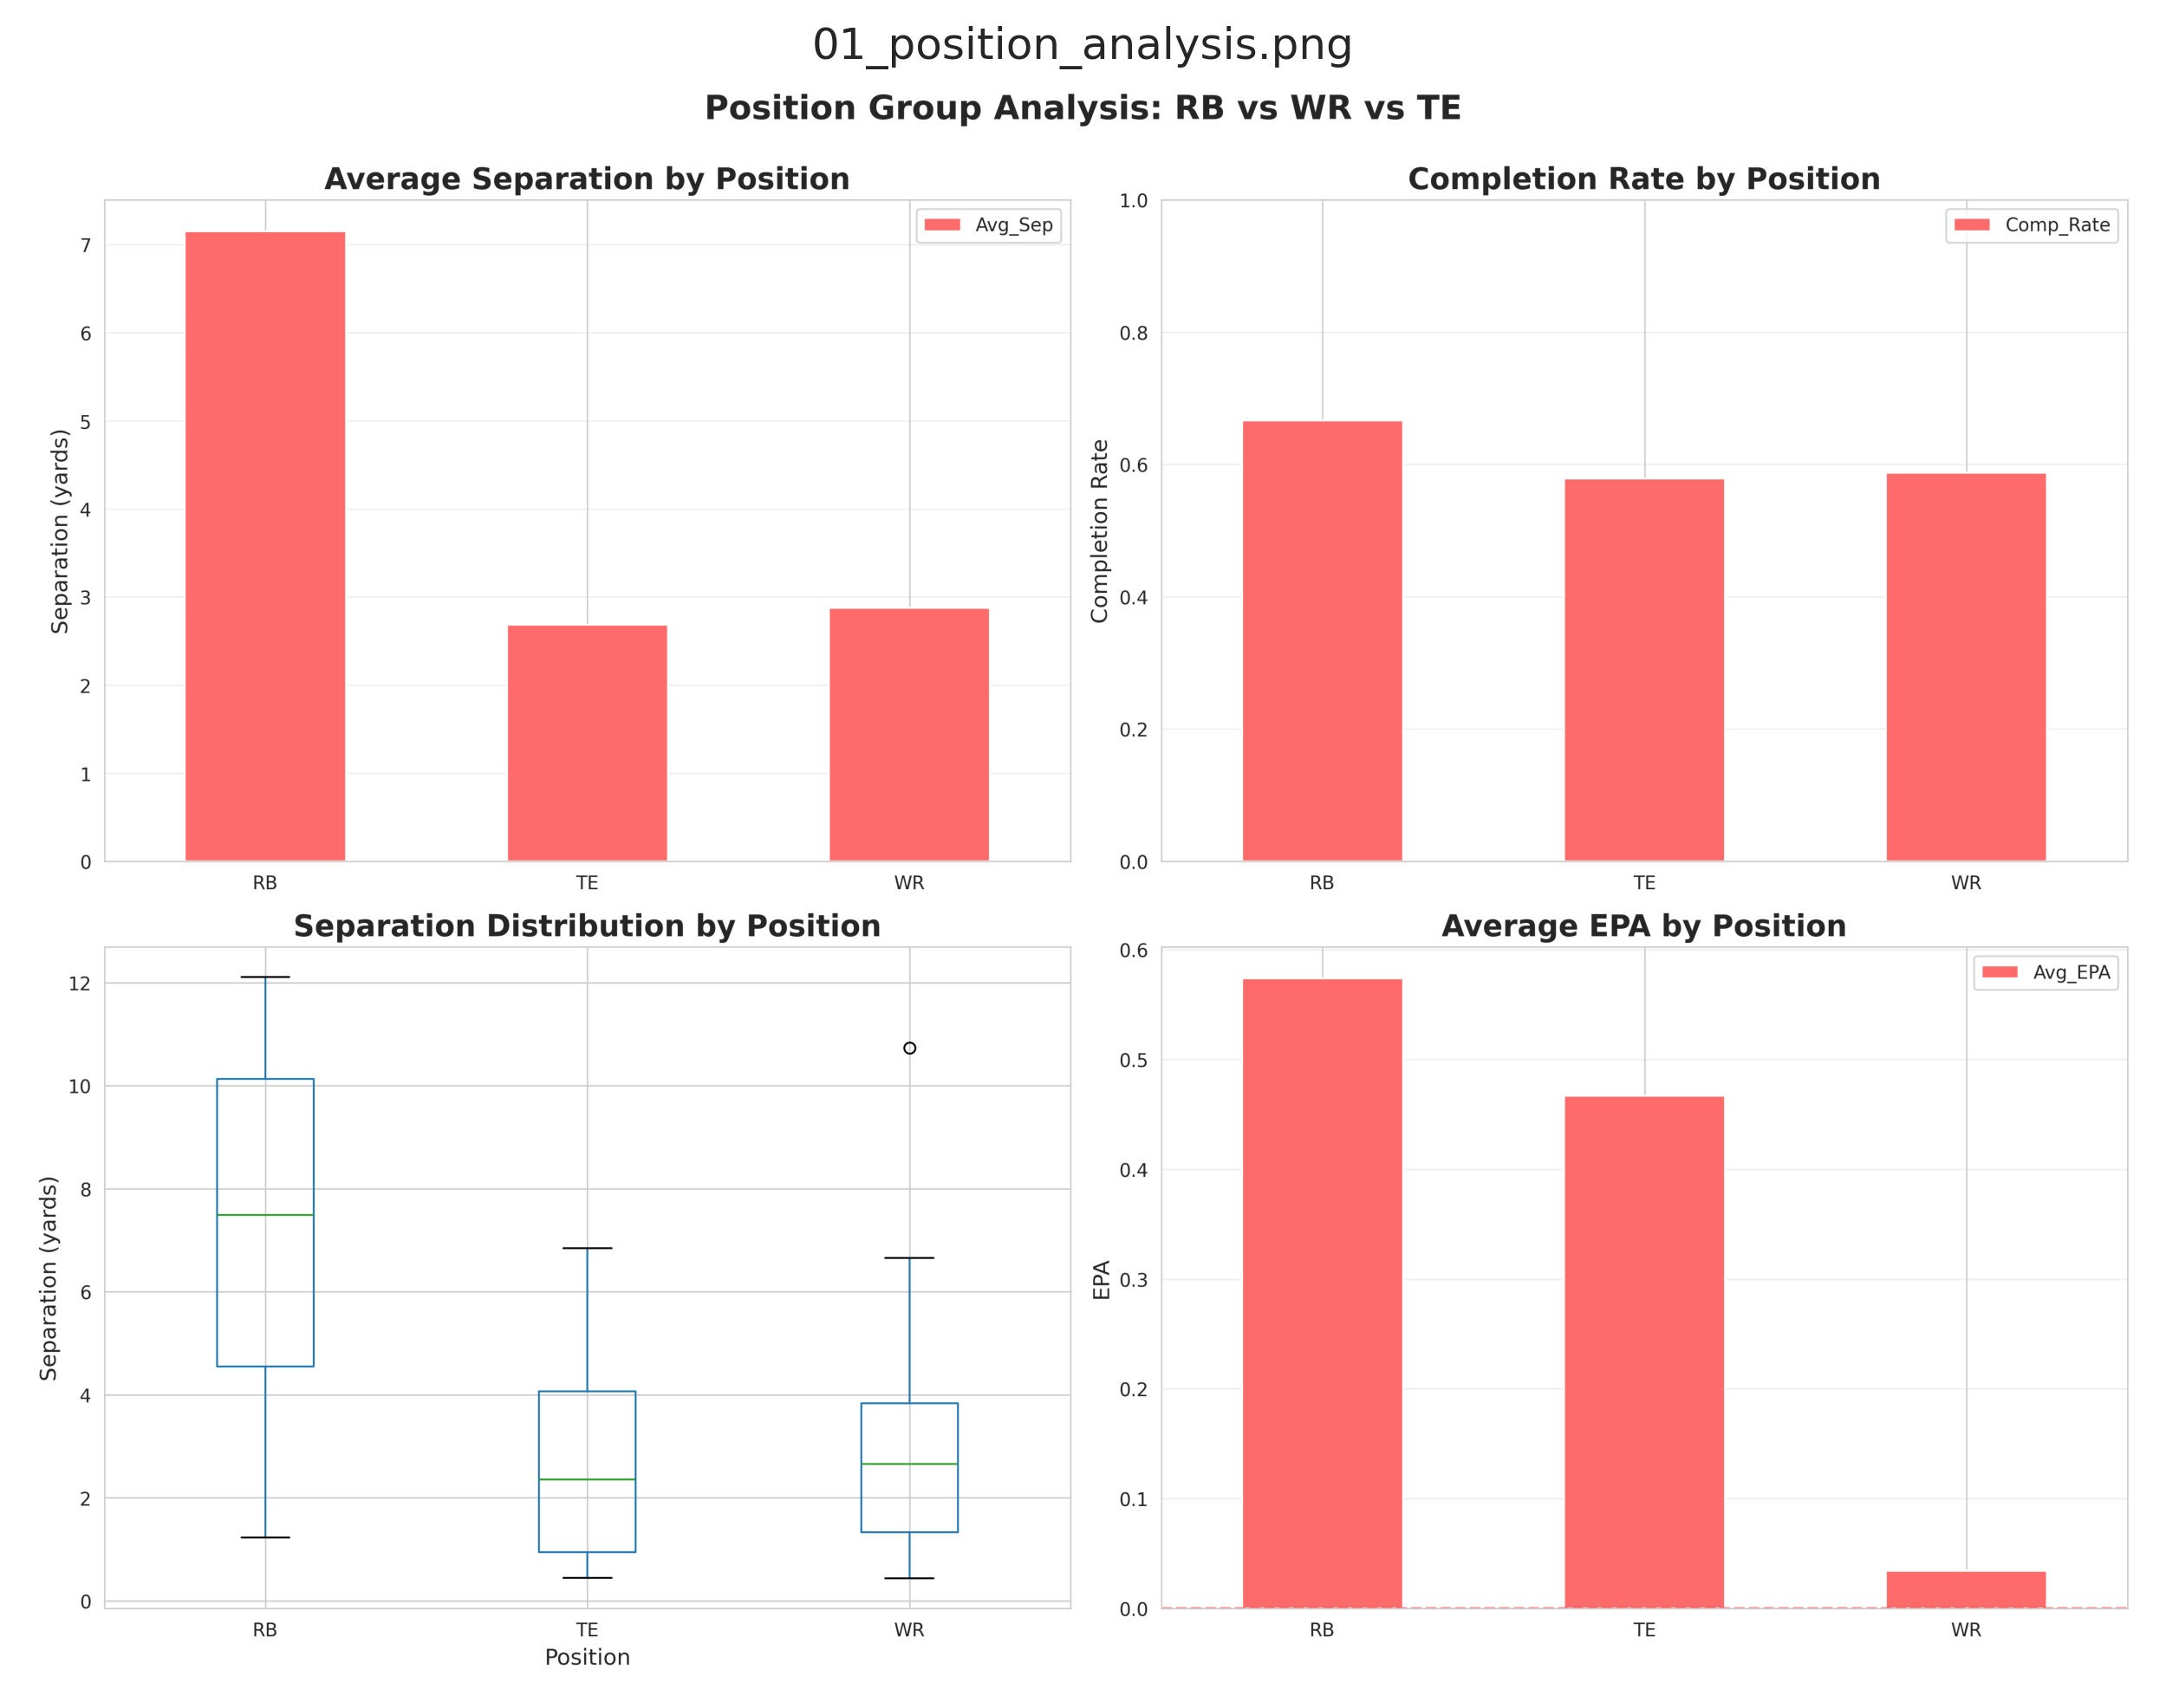

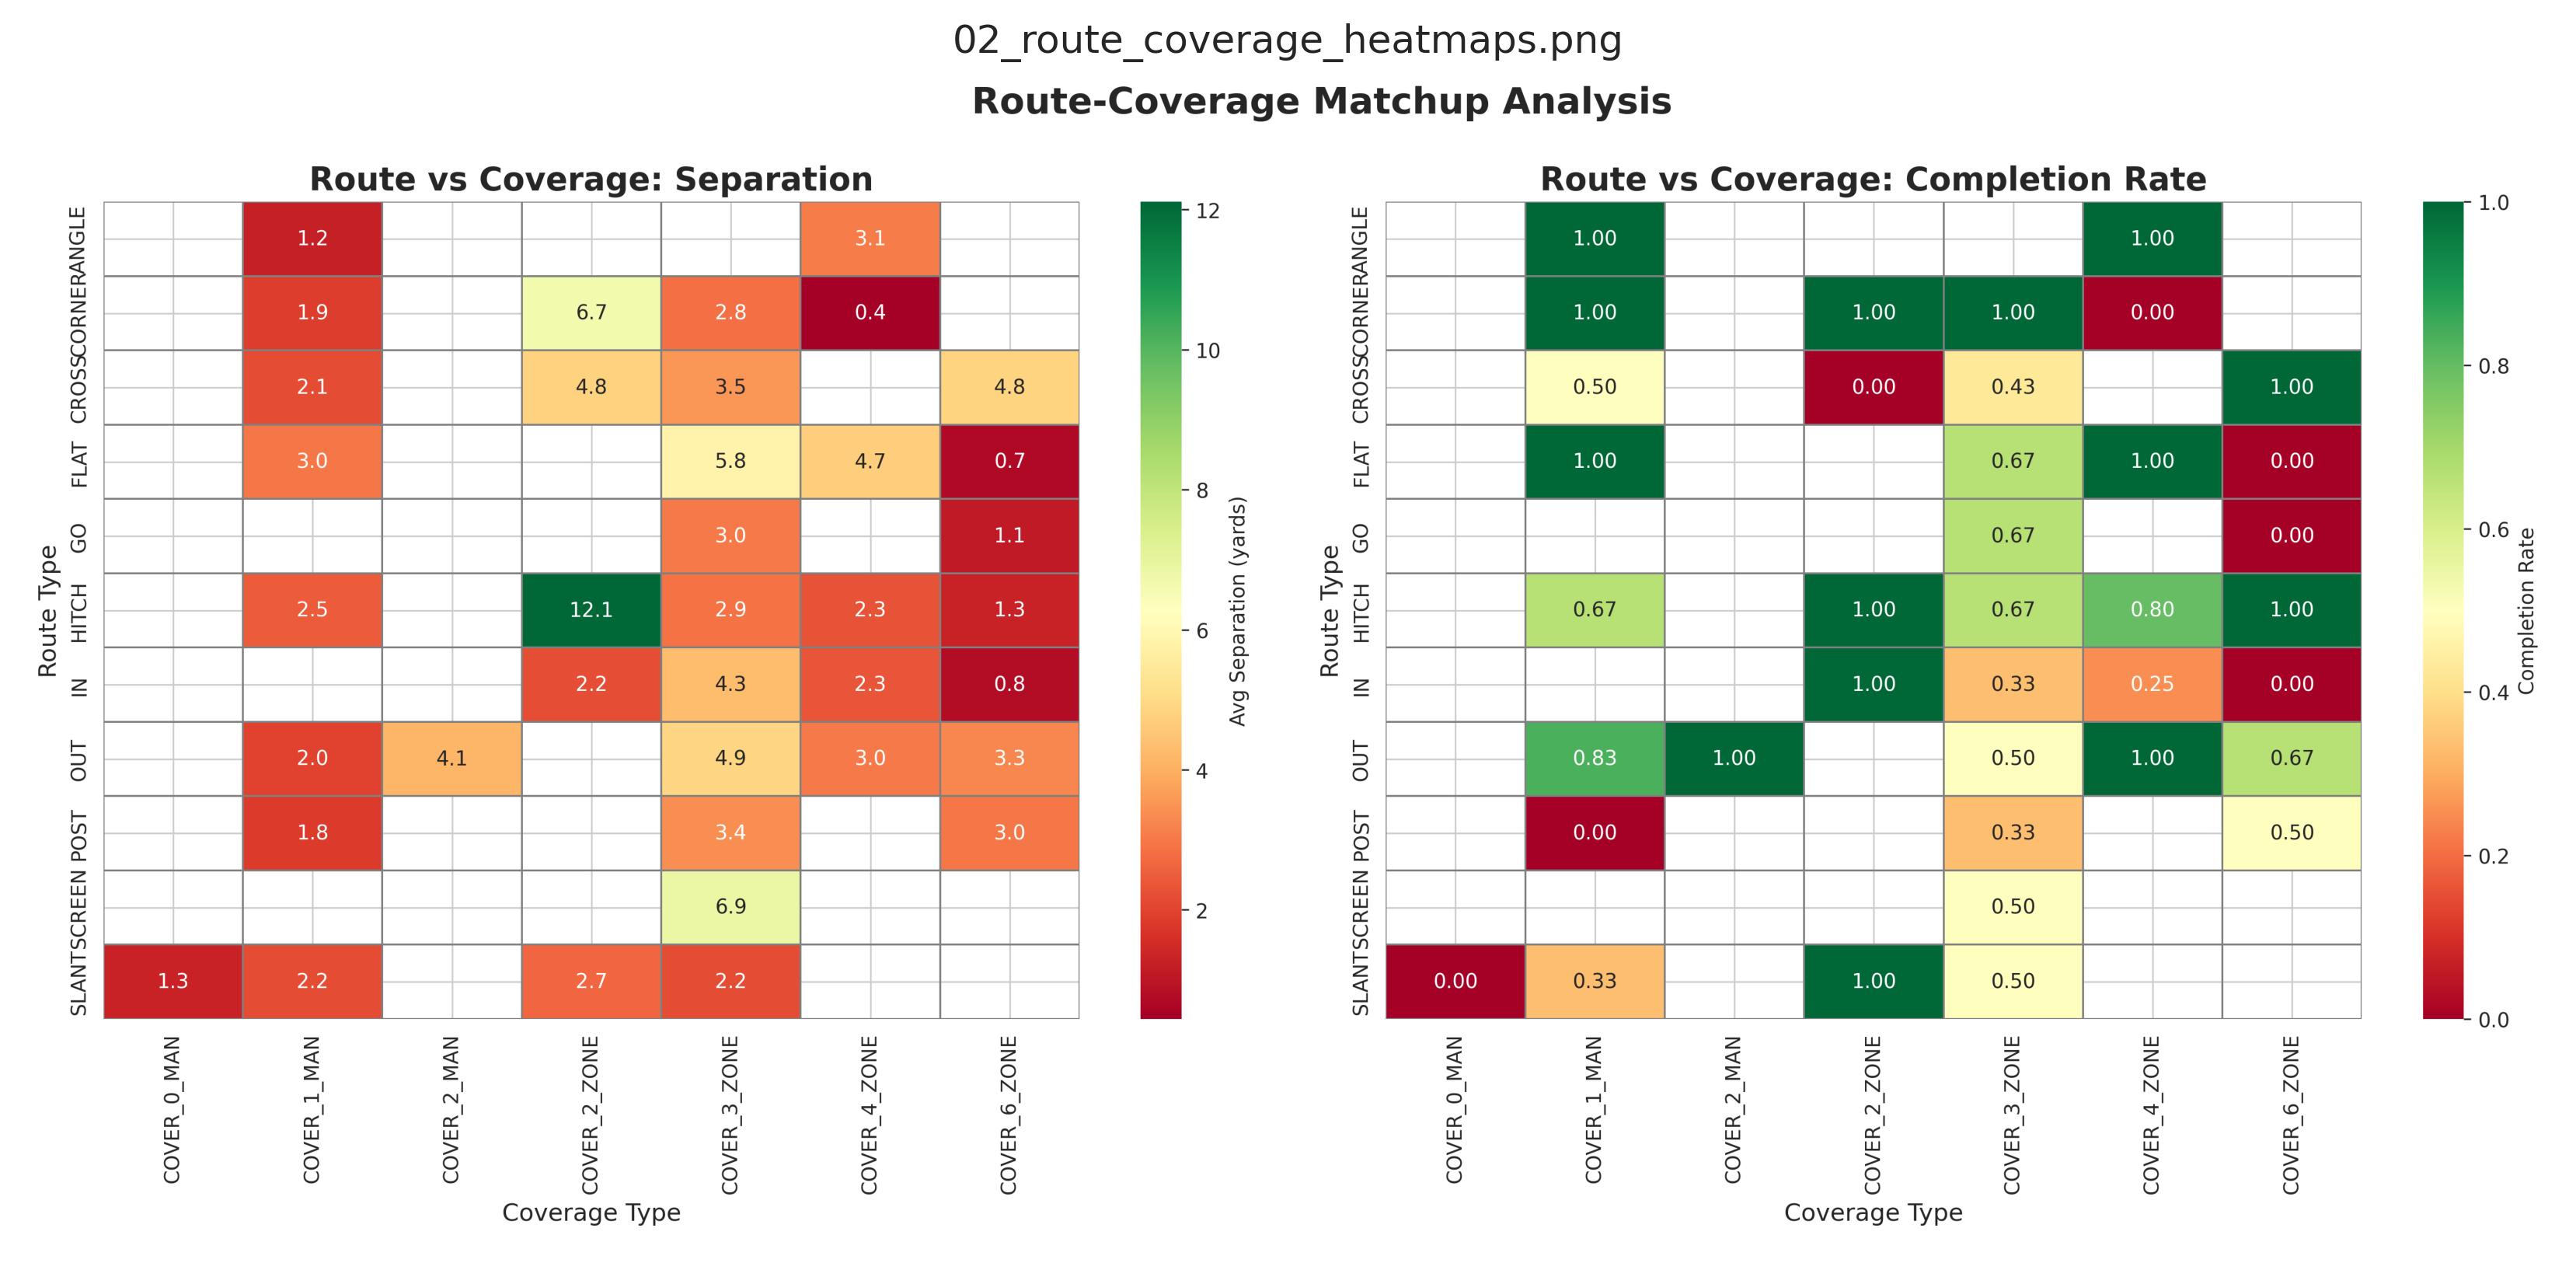

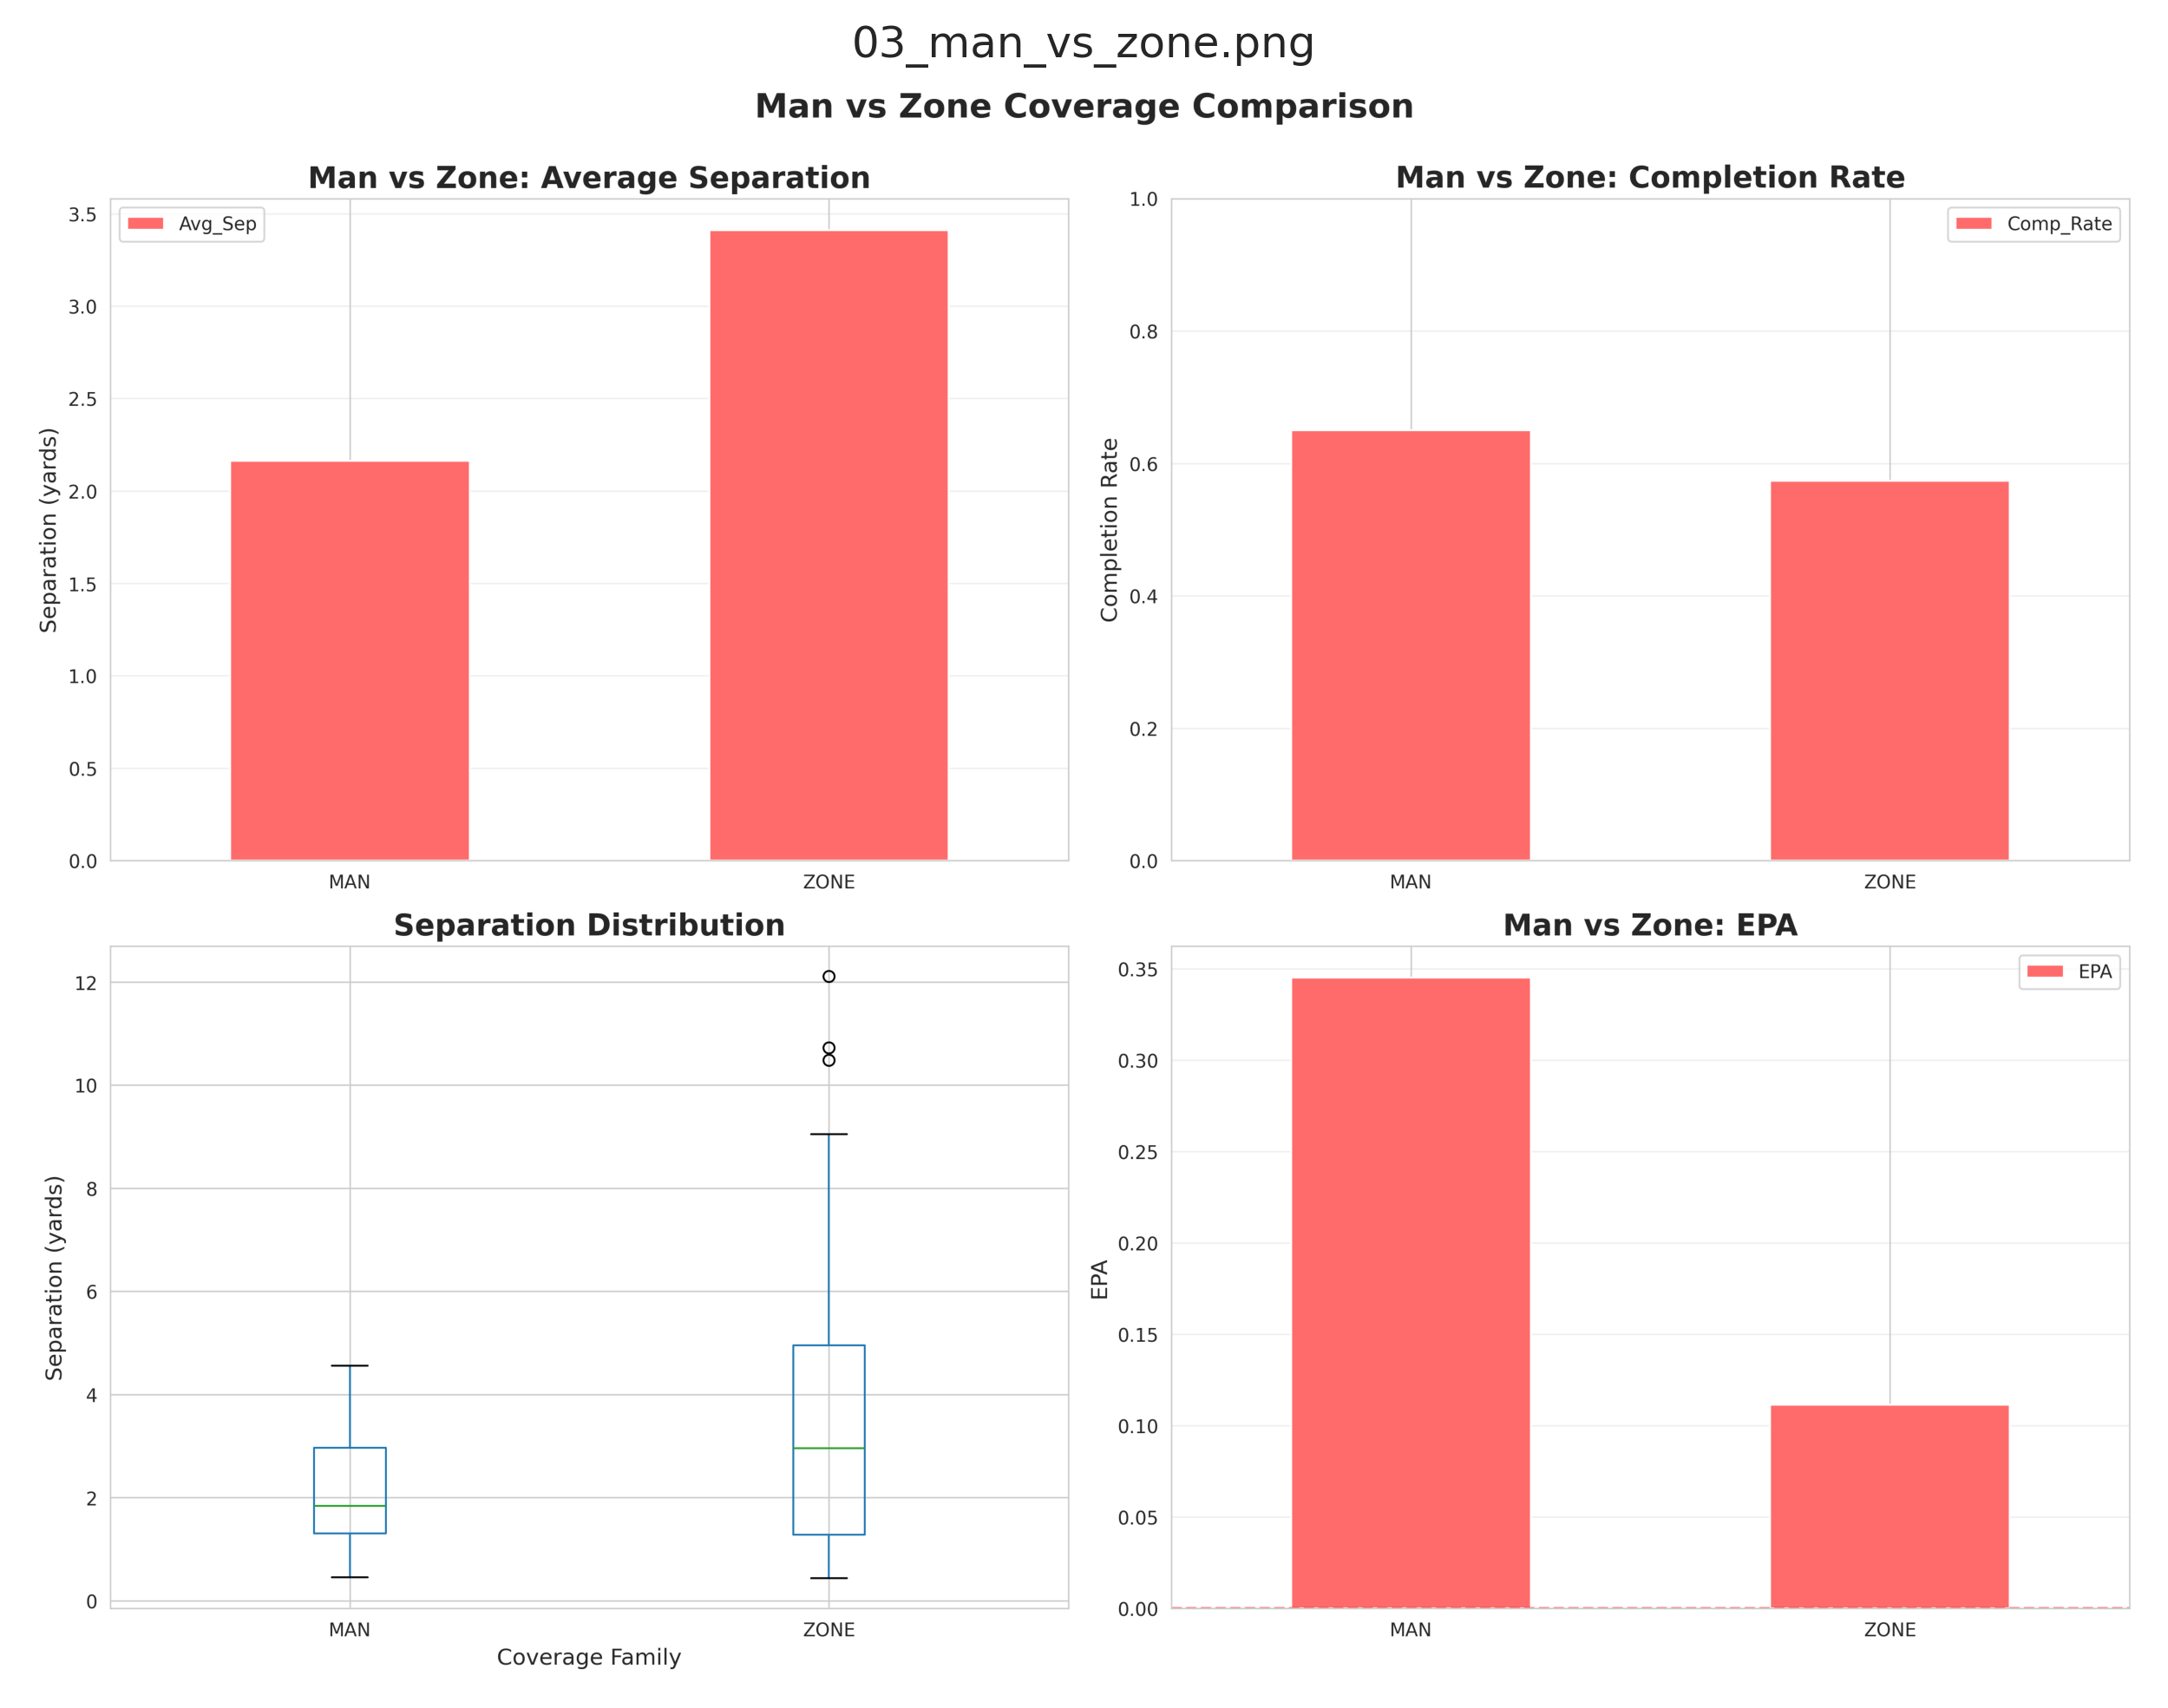

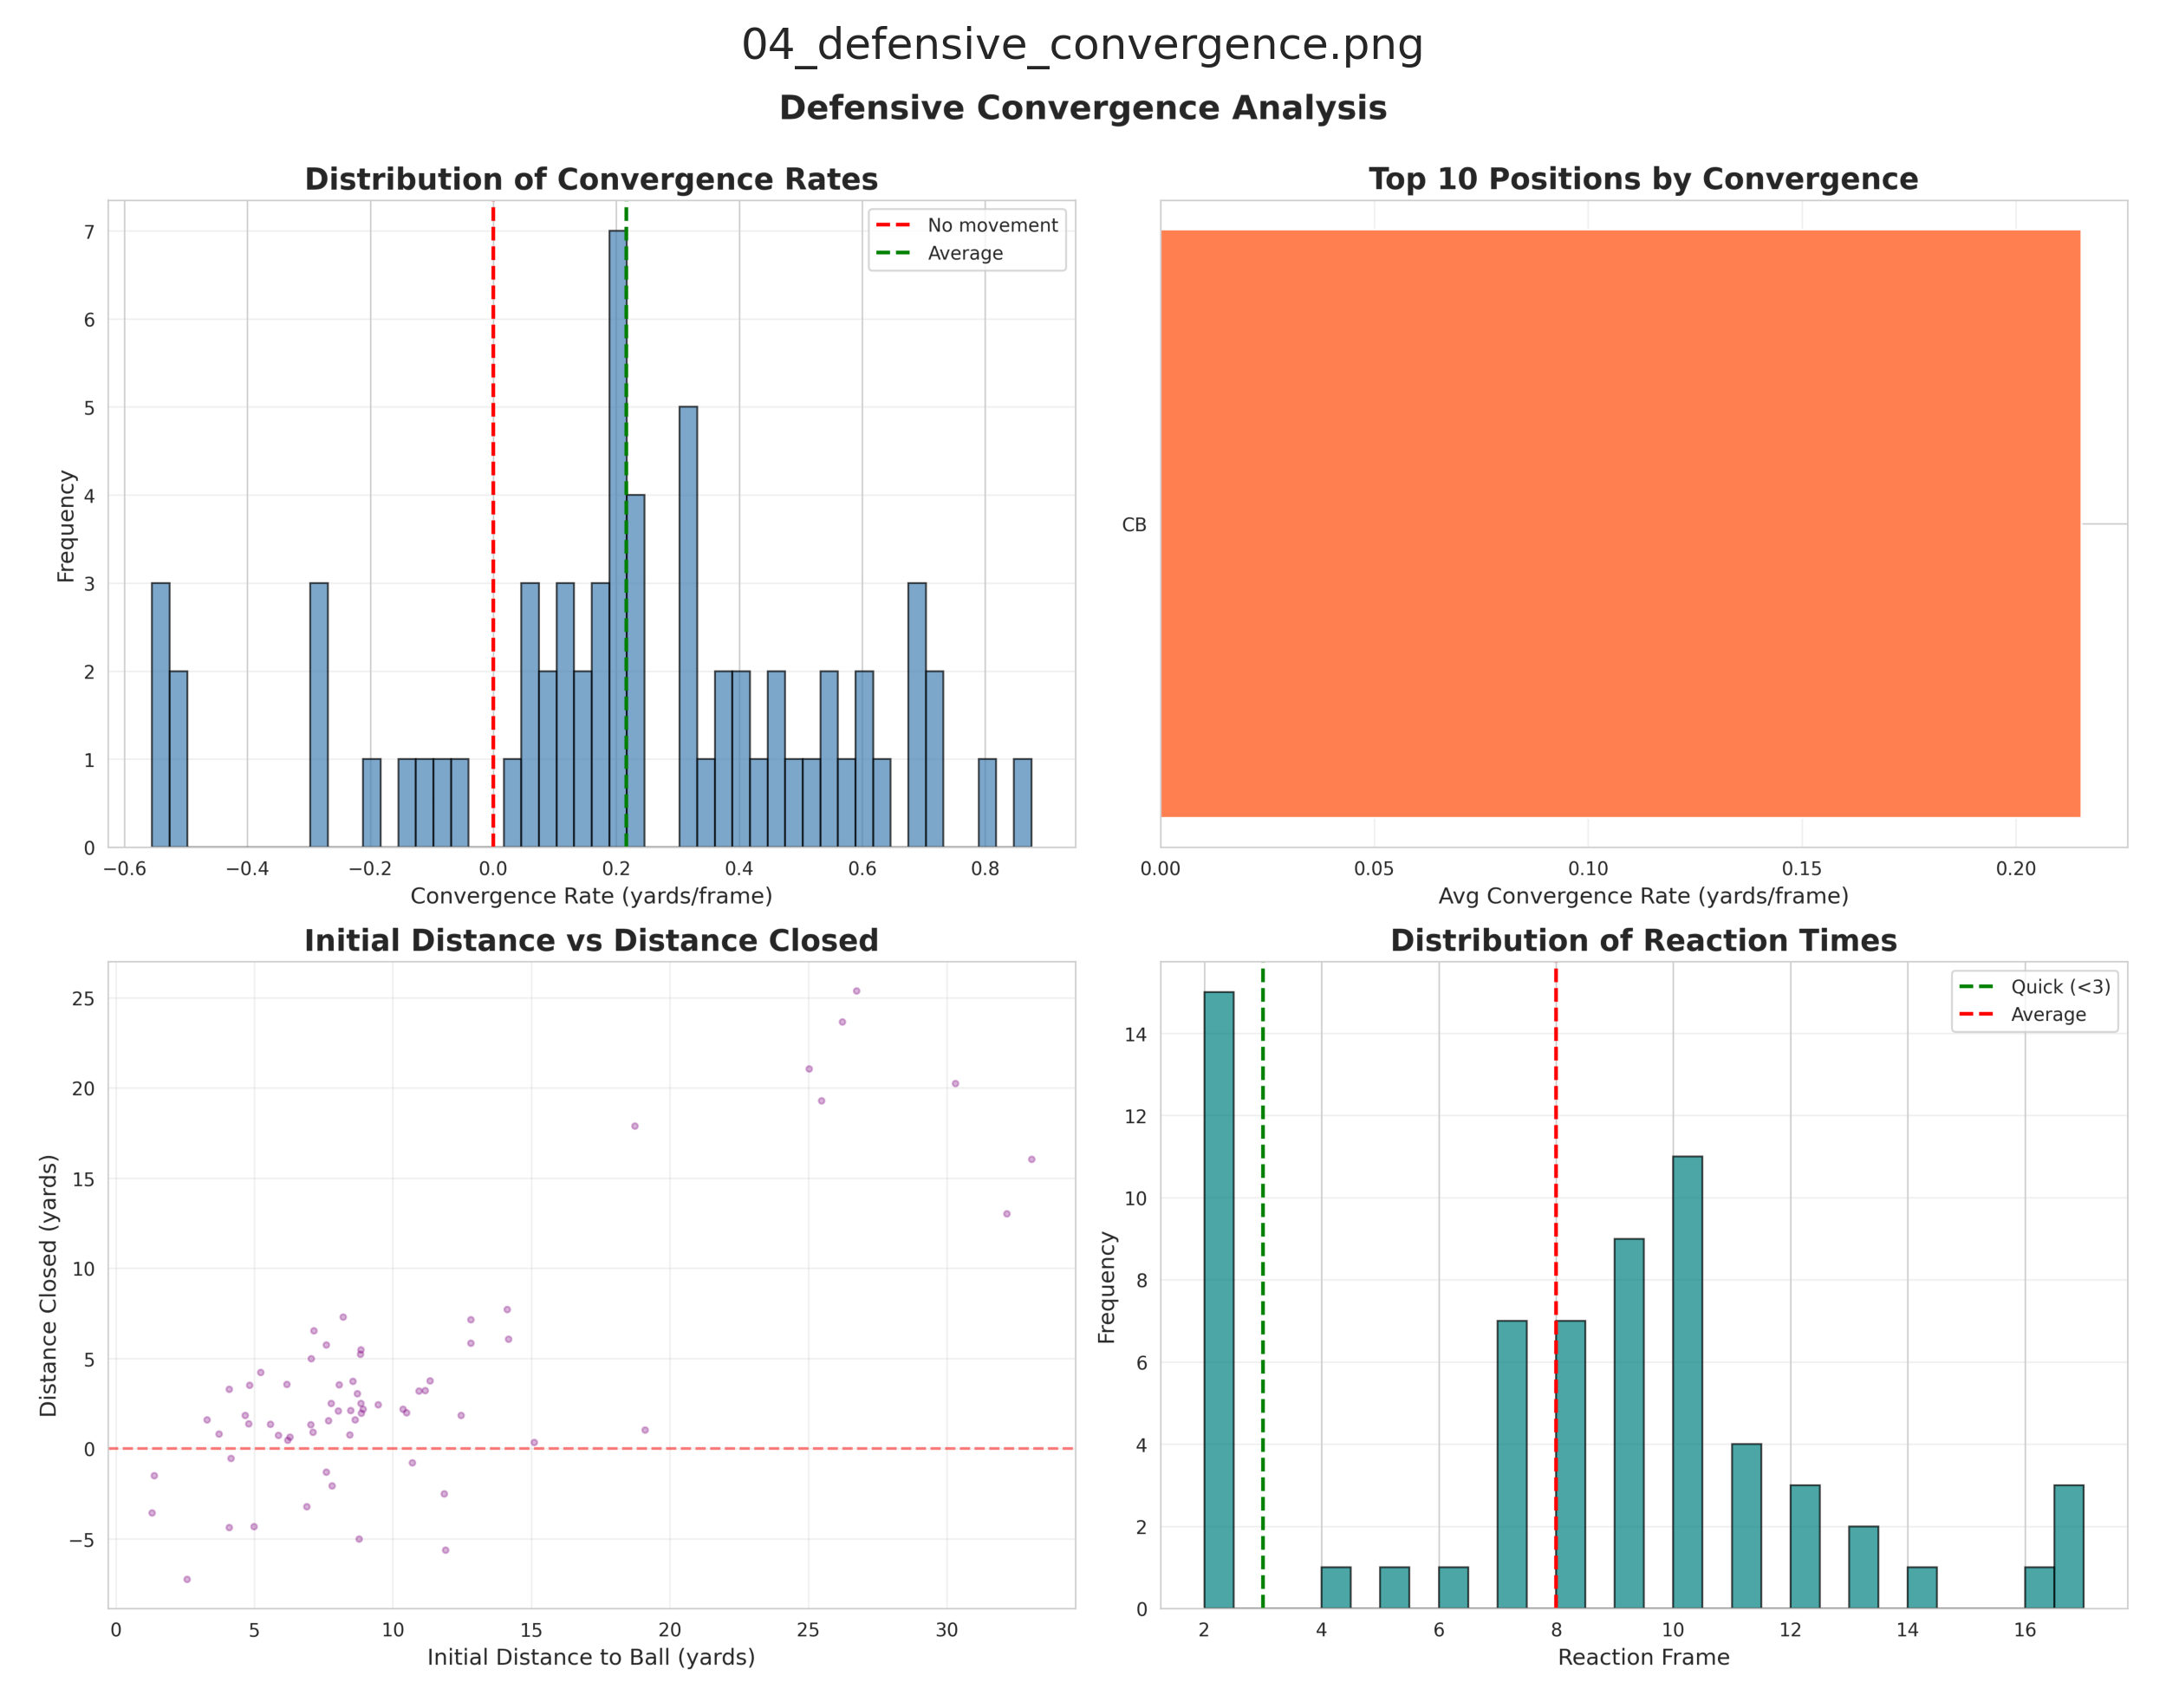

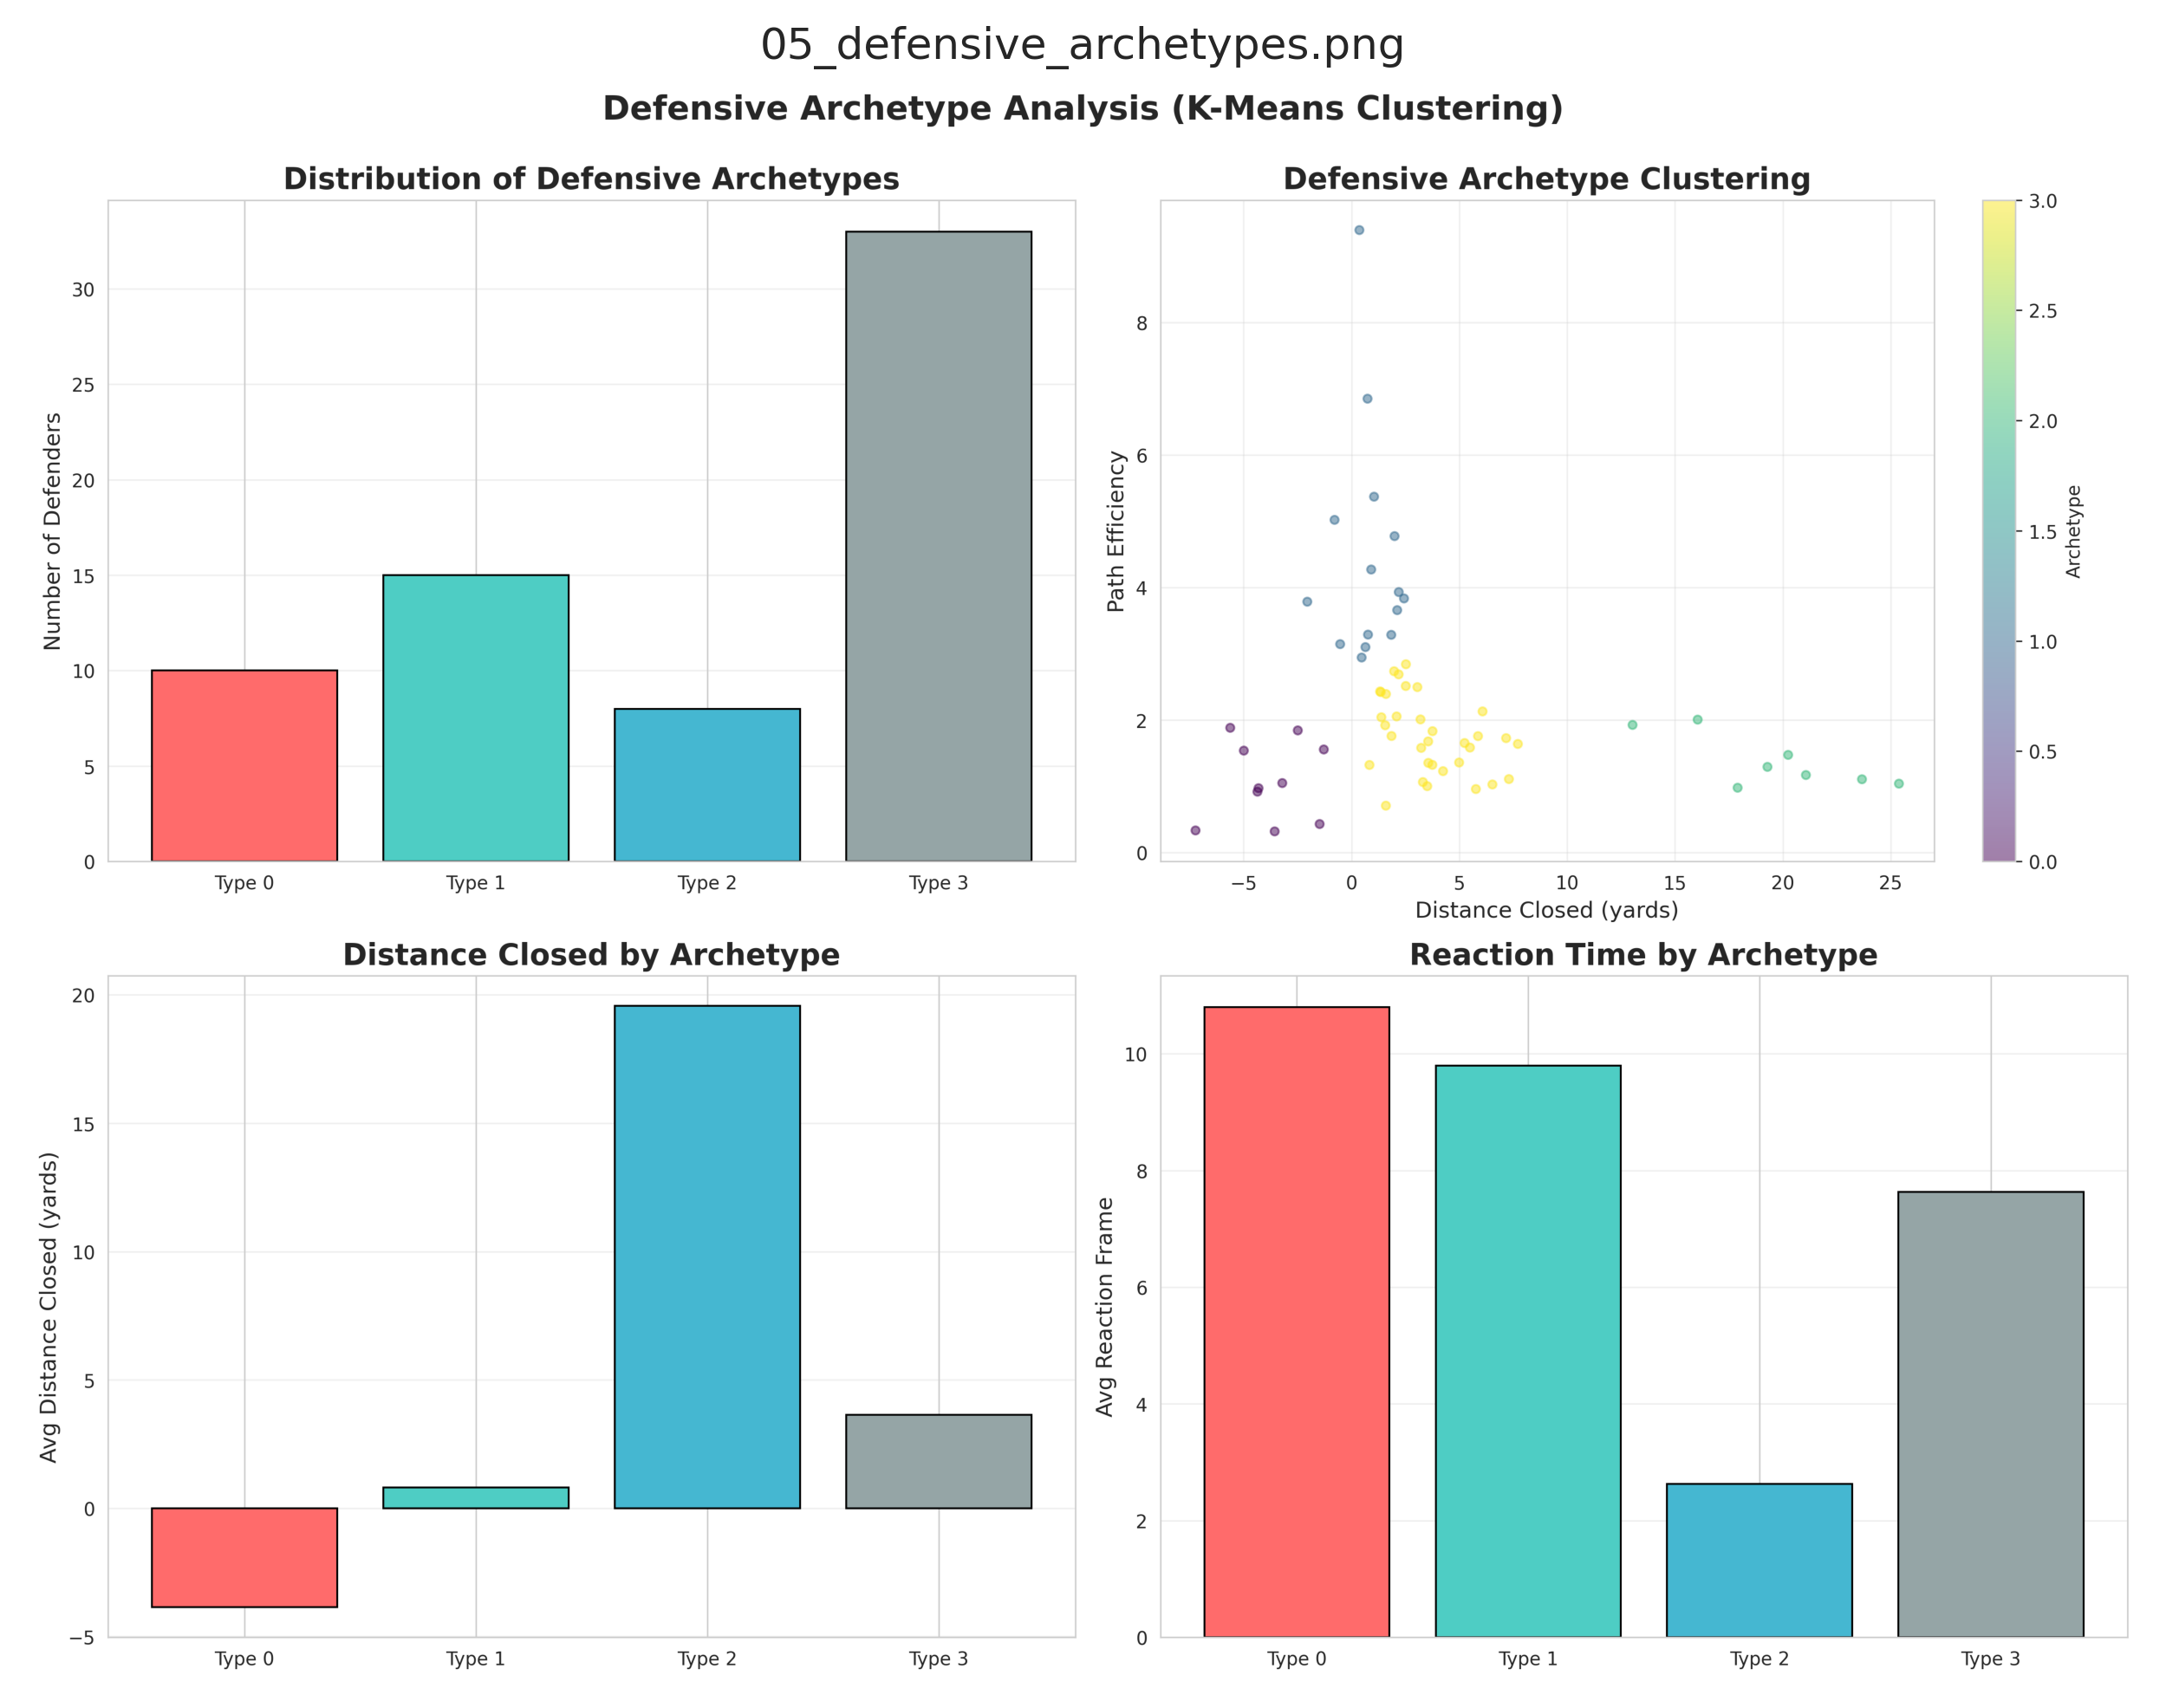

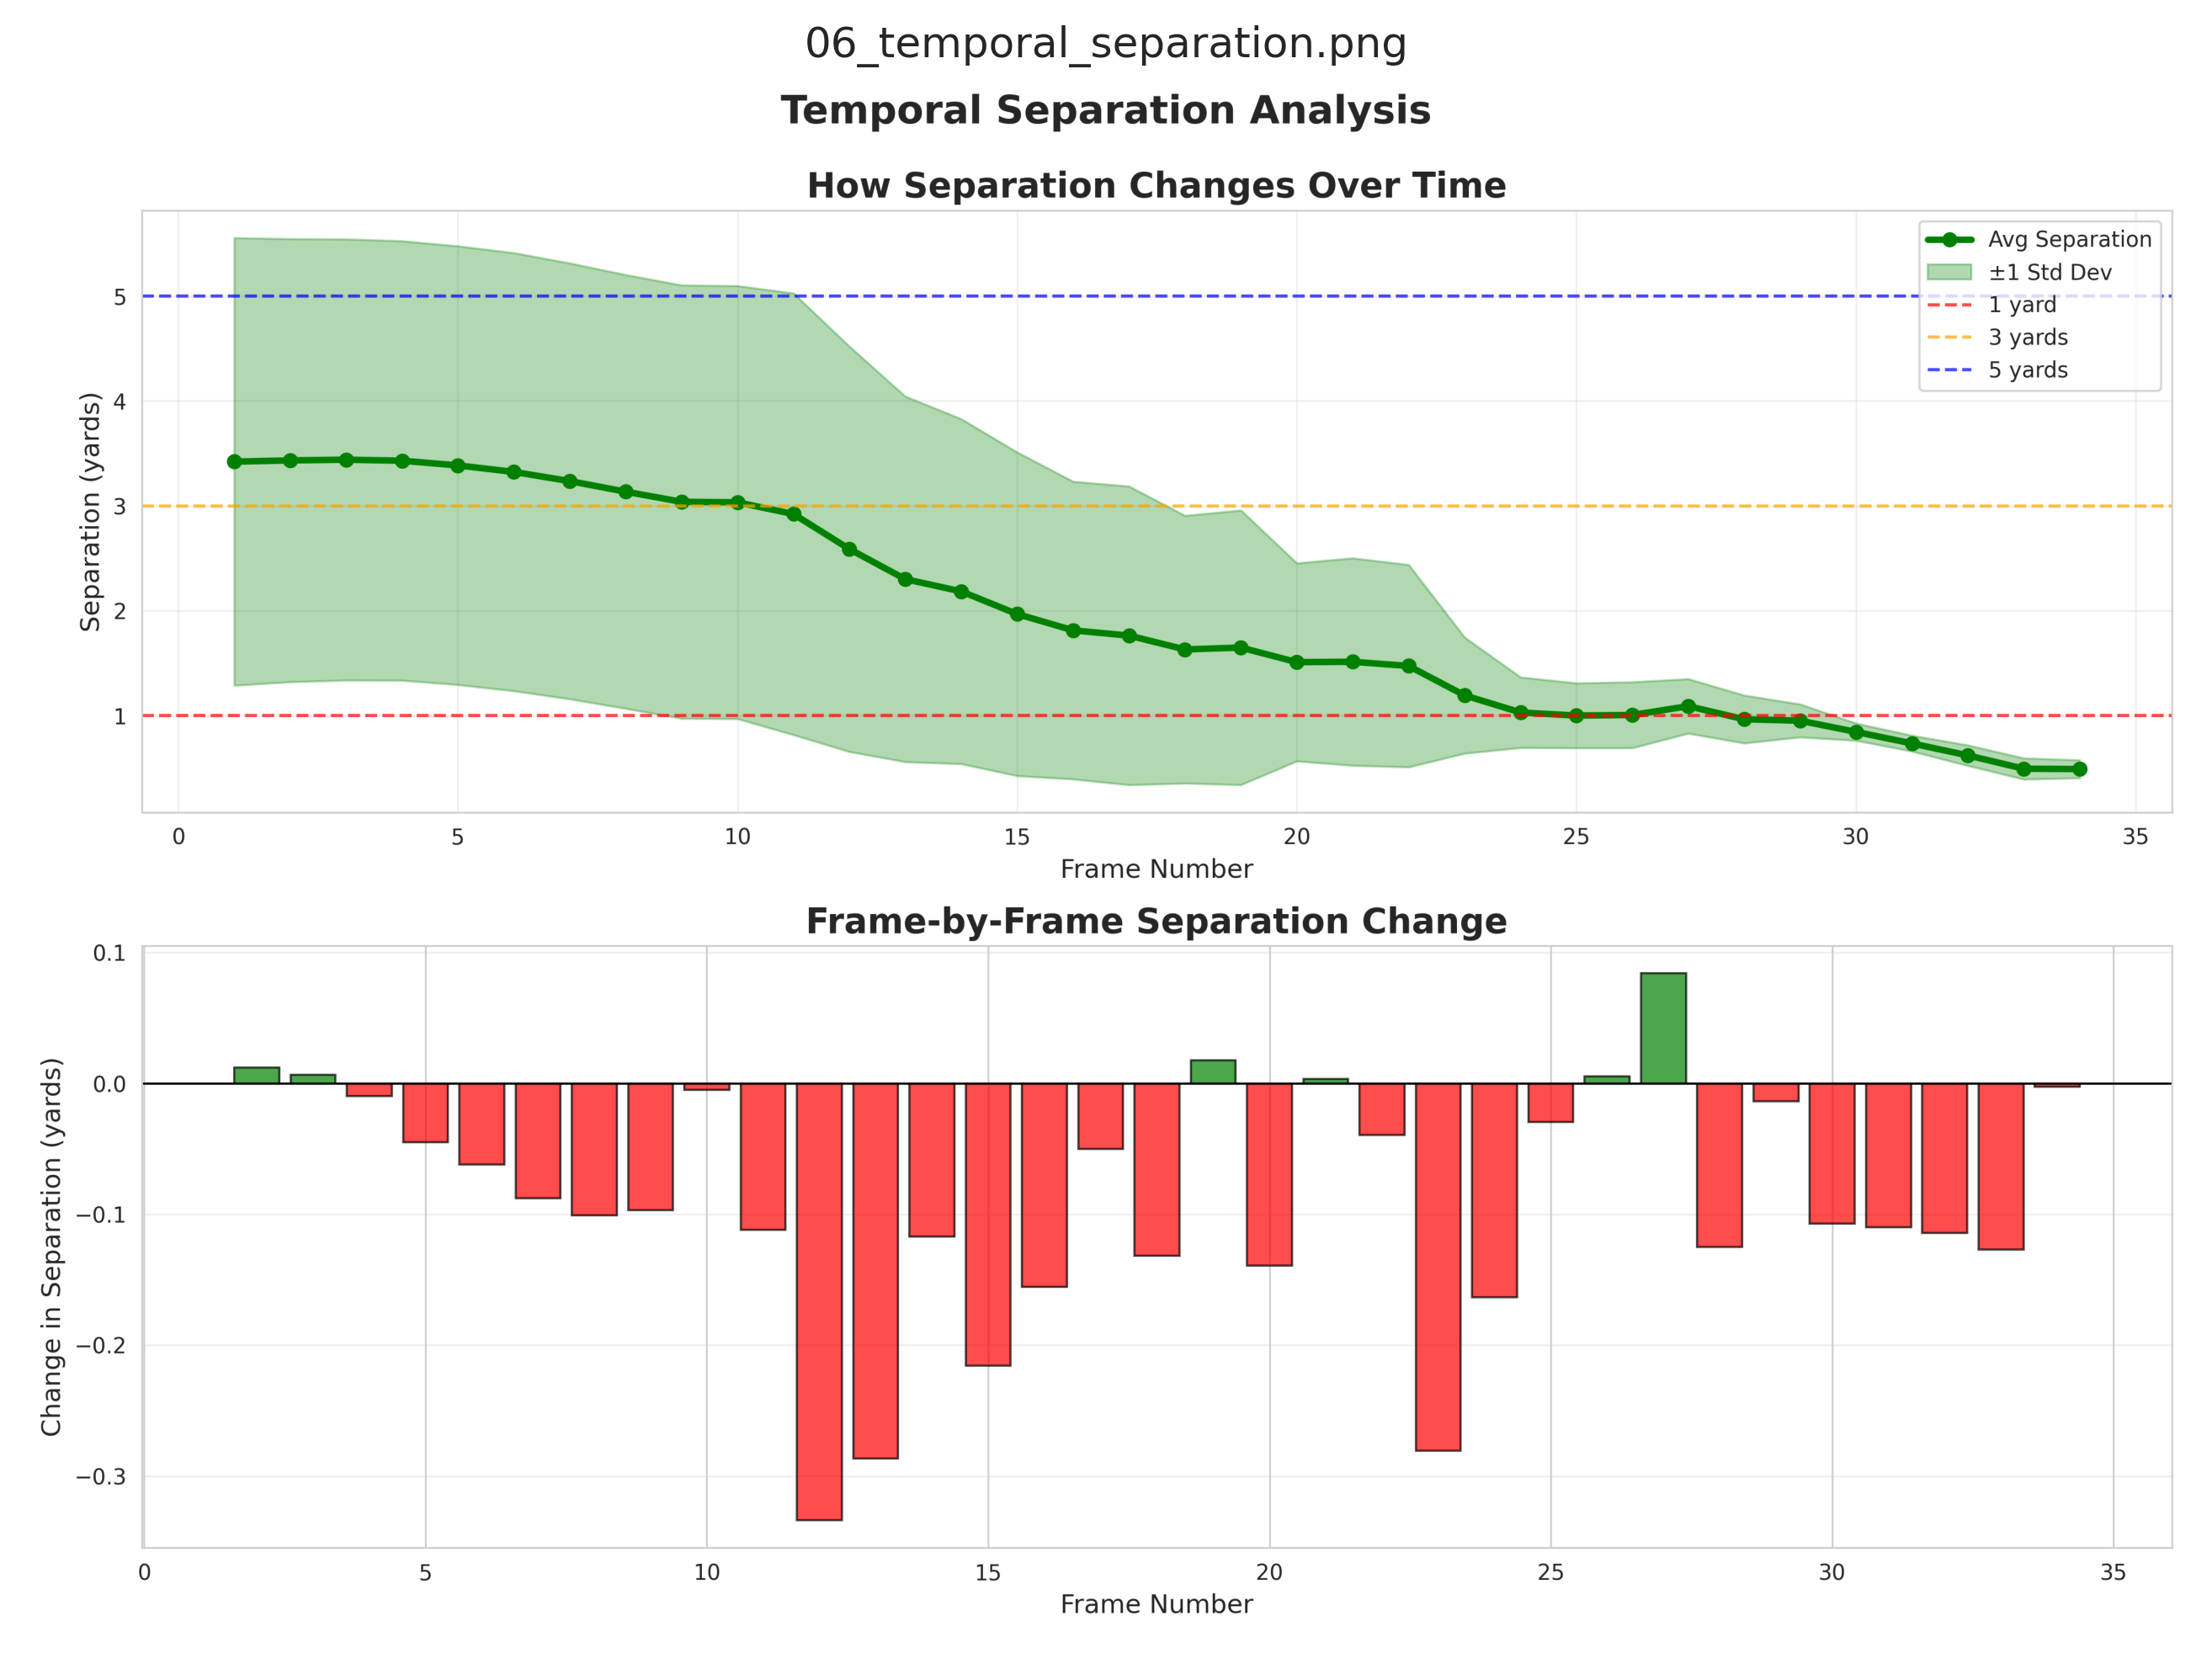

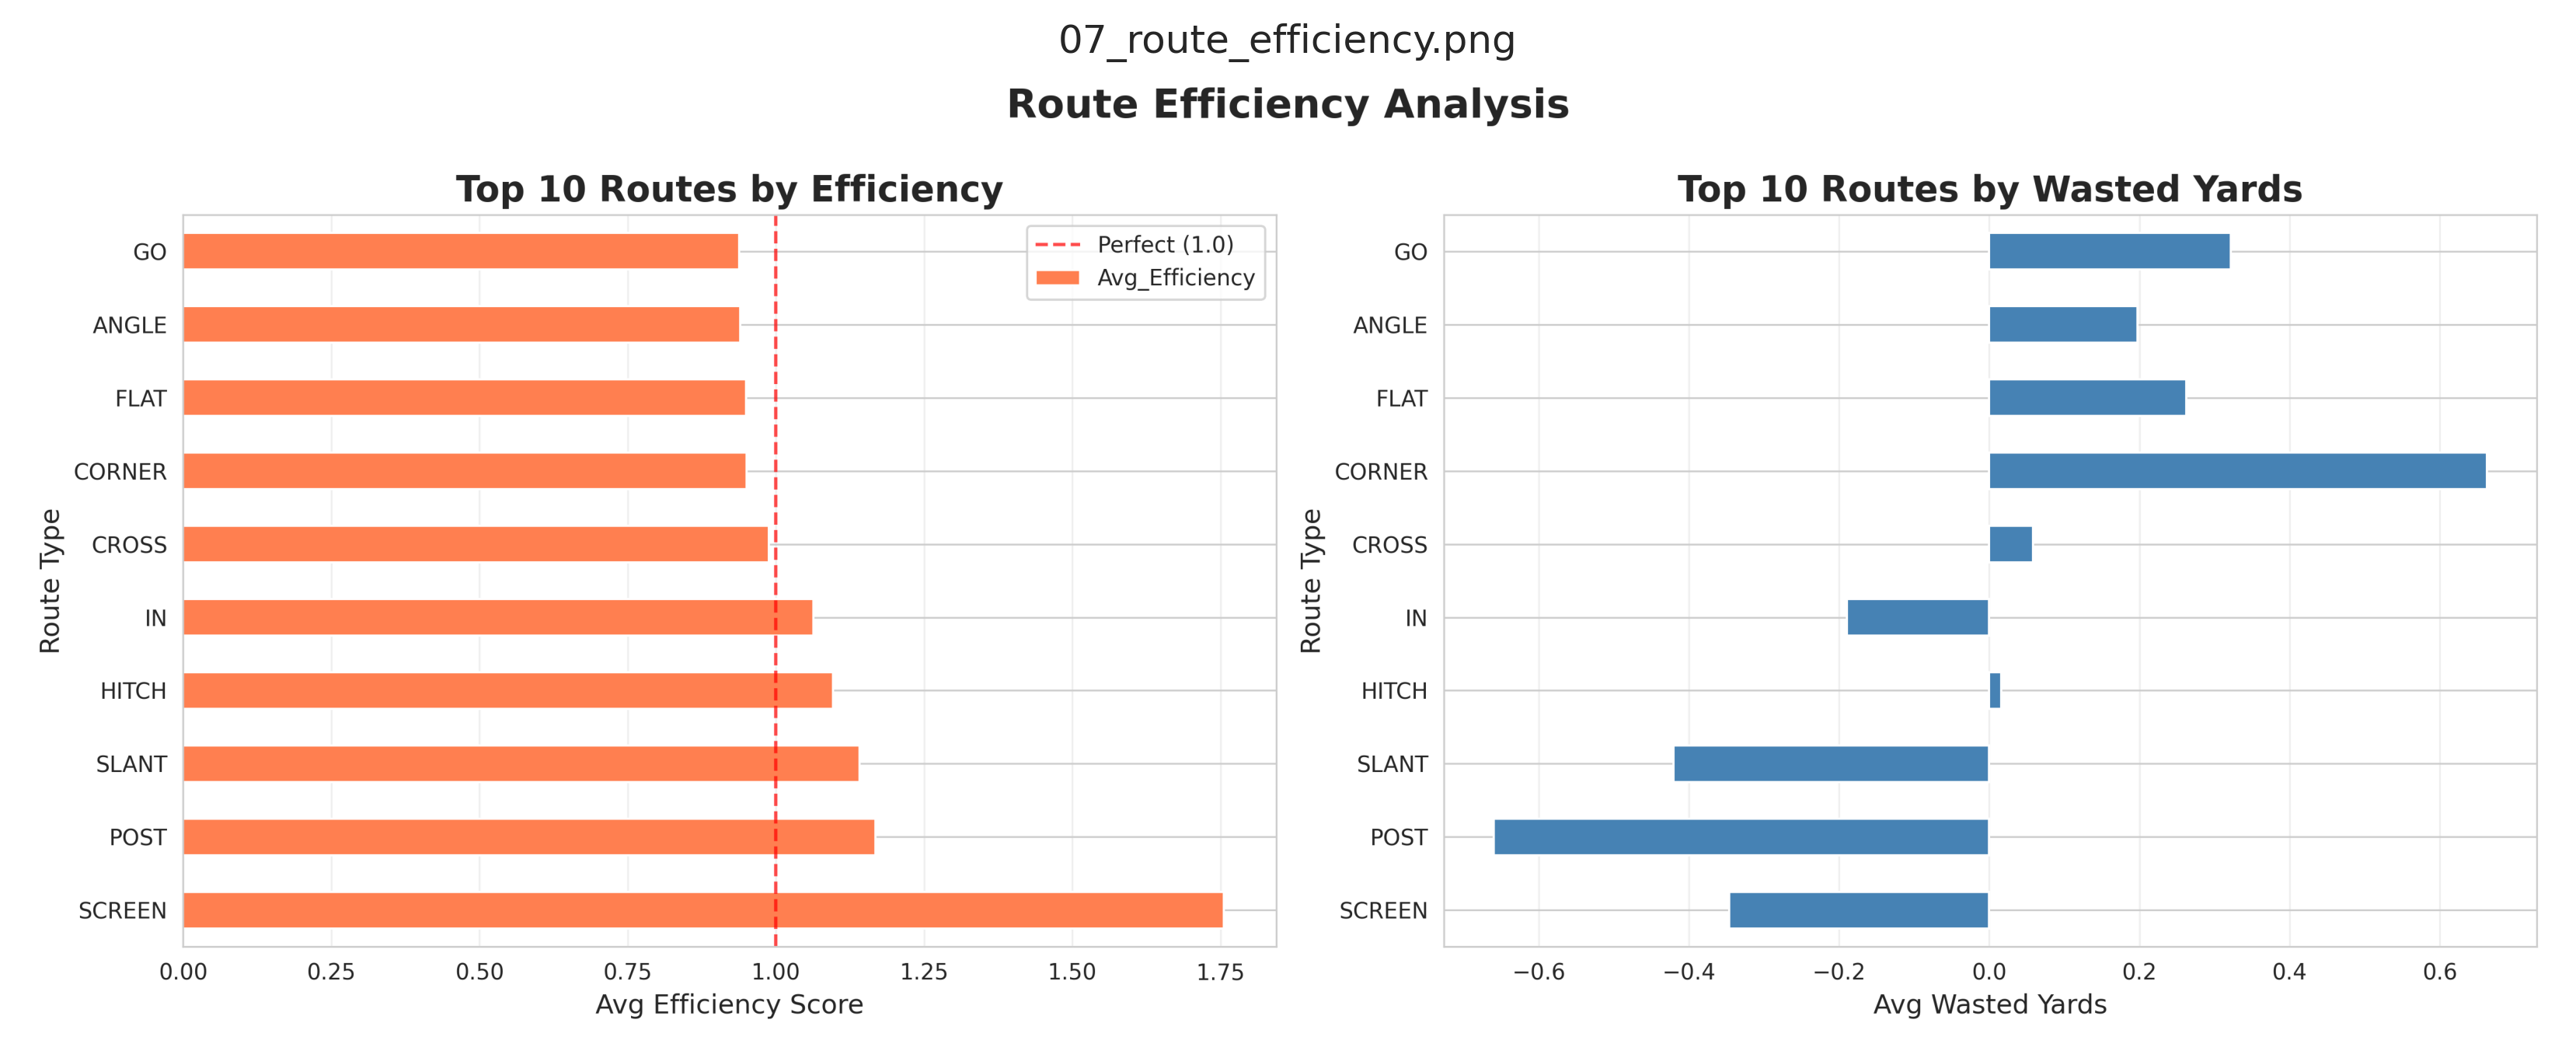

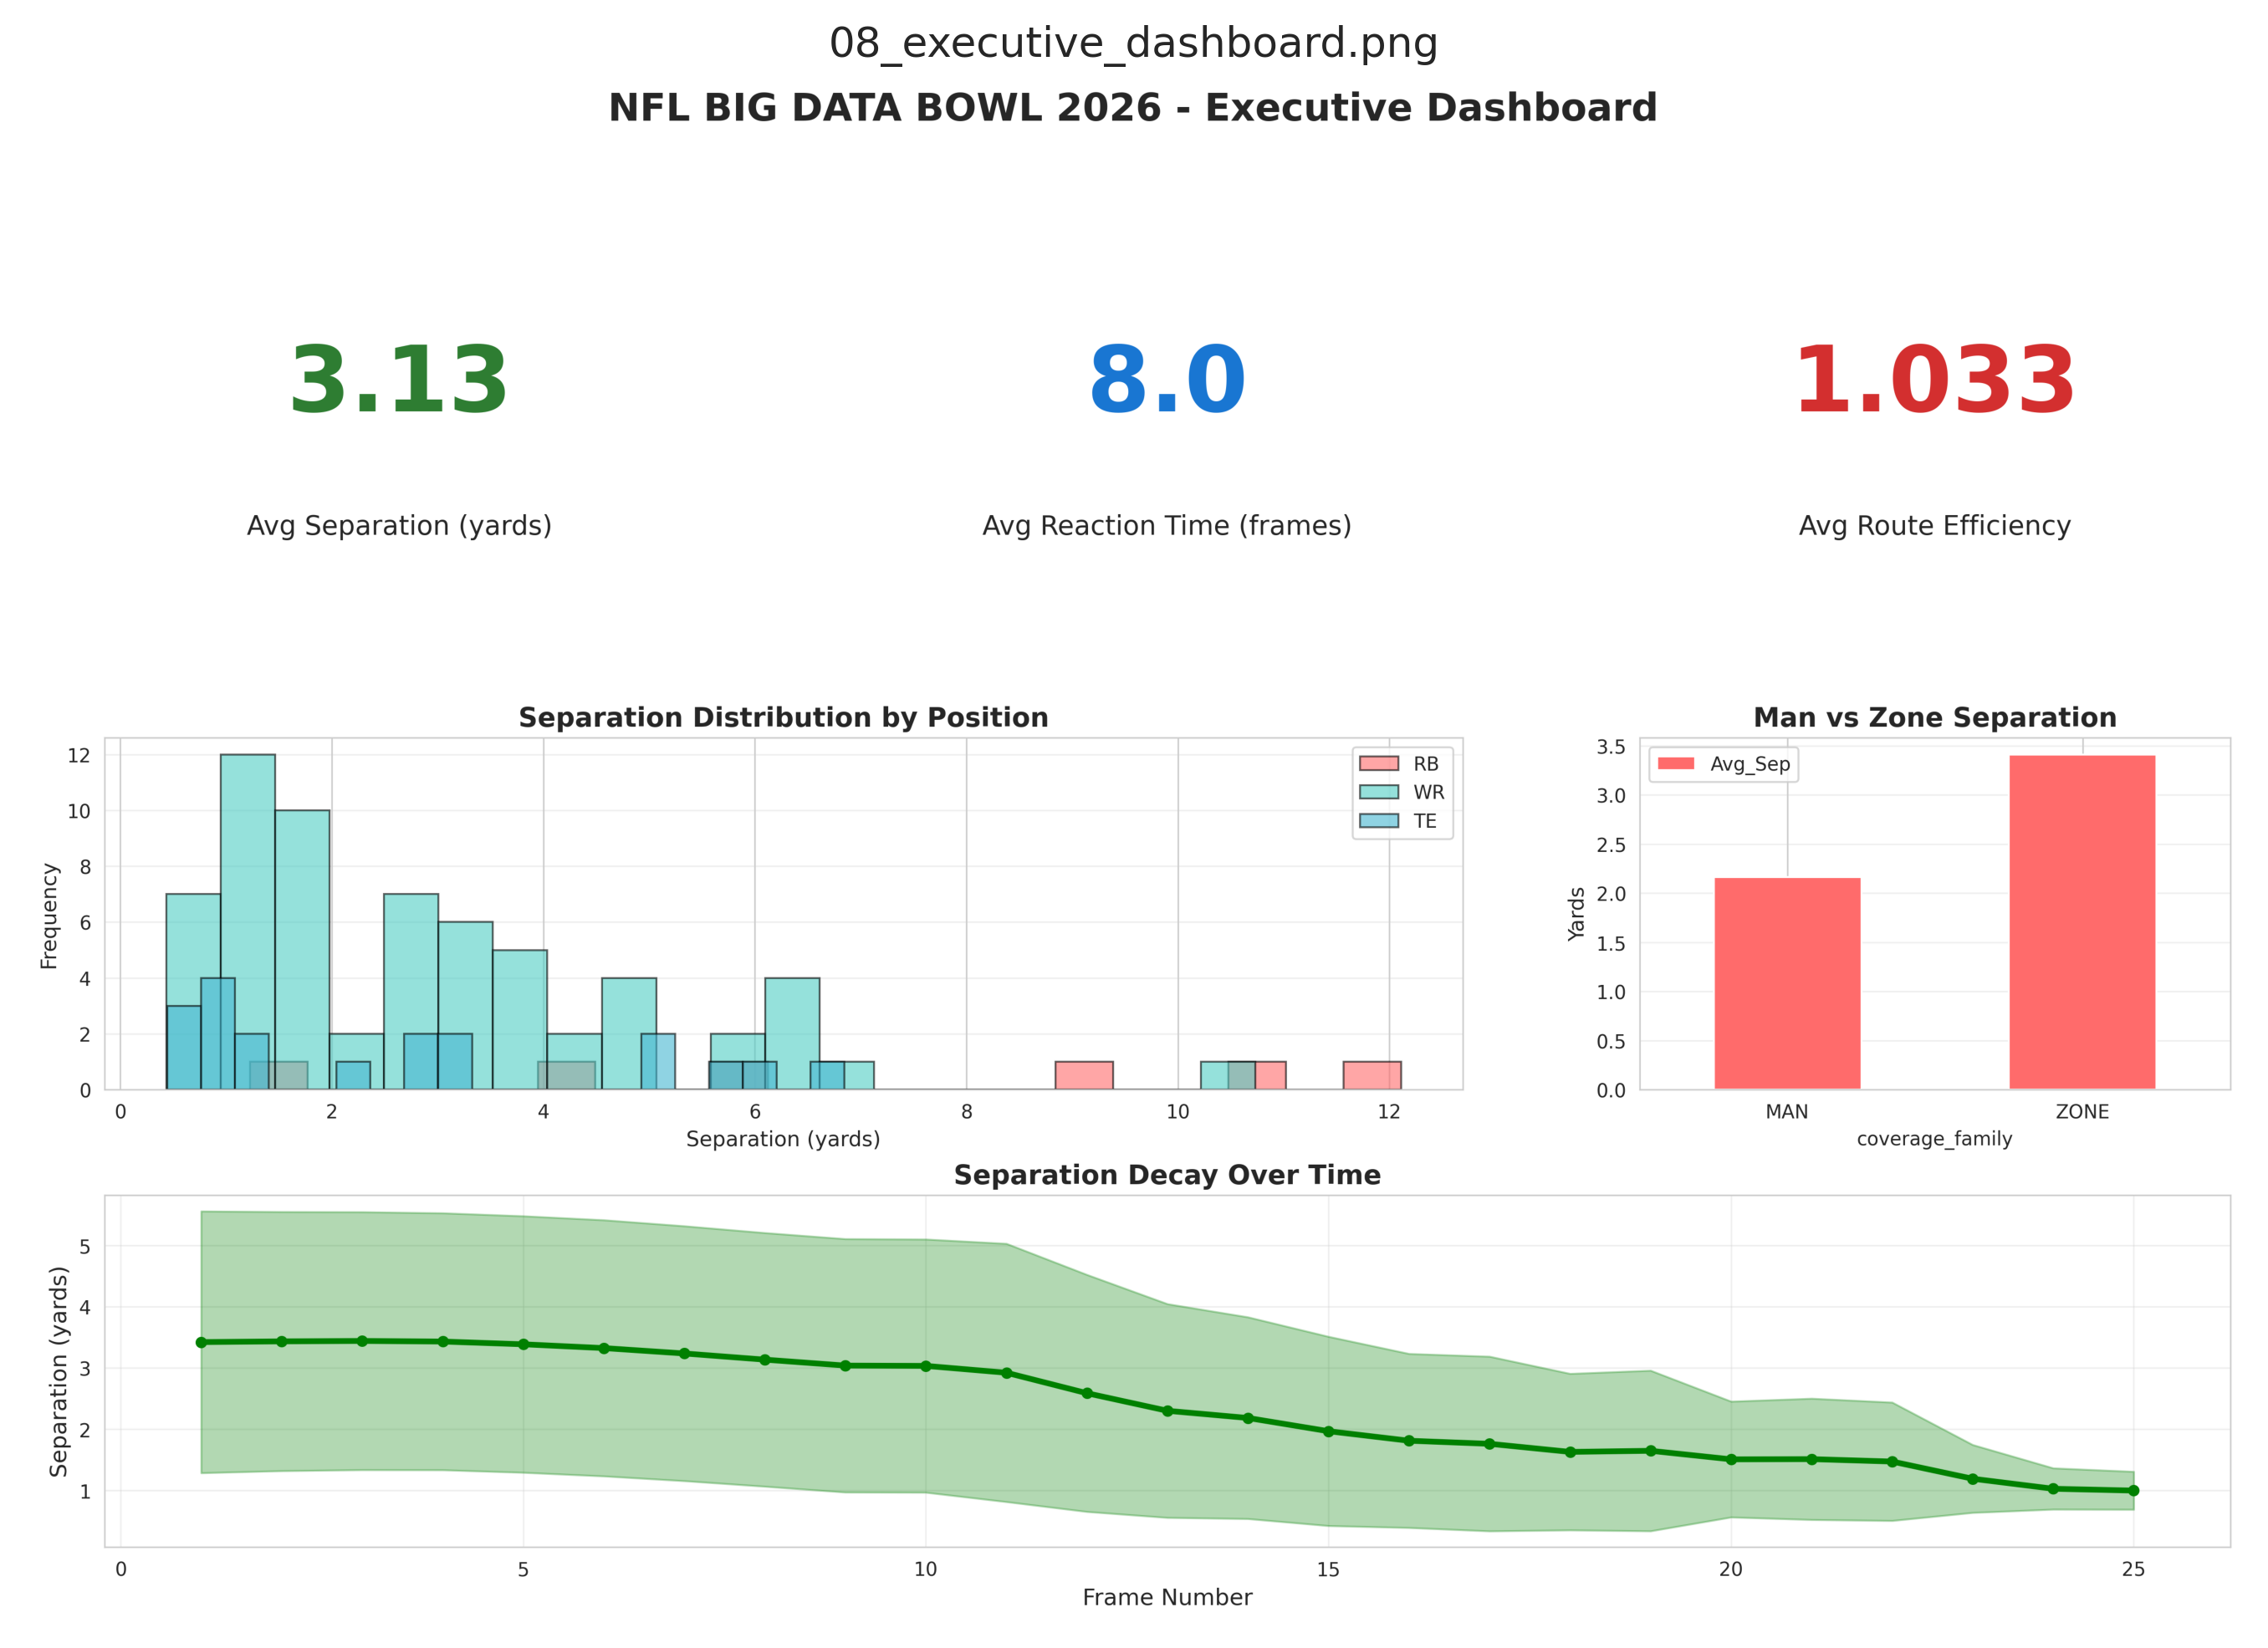

FileNotFoundError: [Errno 2] No such file or directory: 'comprehensive_analysis.png'

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# List of all file names
files = [
    "01_position_analysis.png",
    "02_route_coverage_heatmaps.png",
    "03_man_vs_zone.png",
    "04_defensive_convergence.png",
    "05_defensive_archetypes.png",
    "06_temporal_separation.png",
    "07_route_efficiency.png",
    "08_executive_dashboard.png",
    "comprehensive_analysis.png",
    "data_01_separation_analysis.csv",
    "data_02_defensive_convergence.csv",
    "data_03_route_efficiency.csv",
    "data_04_temporal_separation.csv",
    "data_05_position_statistics.csv",
    "data_06_man_zone_statistics.csv",
    "defensive_heatmap.png",
    "play_animation_broadcast.gif",
    "play_animation_simple.gif",
    "play_frames.png",
    "separation_timeline.png",
    "speed_trails.png"
]

# Filter out .gif and .png files
image_files = [file for file in files if file.endswith(('.gif', '.png'))]

# Function to display the images
def display_images(image_files):
    for image_file in image_files:
        # Open image using PIL
        img = Image.open(image_file)
        
        # Display image using matplotlib
        plt.figure()
        plt.imshow(img)
        plt.title(image_file)
        plt.axis('off')  # Hide axes
        plt.show()

# Call function to display the images
display_images(image_files)


### Project Summary

This project analyzes NFL player tracking data to understand what factors influence pass success using spatial movement metrics, defensive reaction timing, and route efficiency. We discovered that early receiver separation and defender reaction speed significantly impact completion probability, achieving ~0.69 ROC-AUC in predictive modeling. Clustering analysis revealed distinct defensive behavior archetypes, while temporal tracking showed separation consistently decreases as plays develop. These findings demonstrate how movement analytics can provide actionable insights for strategy, player evaluation, and real-time decision systems.
